In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from statsmodels.nonparametric.smoothers_lowess import lowess

from pandas.tseries.holiday import USFederalHolidayCalendar

## Early data Work

### Data import

In [2]:
DATA_DIR = "./SPX_Options"

expiry_pattern = re.compile(r"SPX(\d{4}-\d{2}-\d{2})")

dfs = []

for fname in os.listdir(DATA_DIR):

    if not fname.endswith(".csv"):
        continue

    match = expiry_pattern.search(fname)
    if match is None:
        continue

    expiry = pd.to_datetime(match.group(1))

    tmp = pd.read_csv(os.path.join(DATA_DIR, fname))
    tmp["expiry"] = expiry
    tmp["source_file"] = fname

    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["call_mid"] = 0.5 * (df["call_bid"] + df["call_ask"])

df = df[
    (df["call_mid"] > 0) &
    ((df["call_ask"] - df["call_bid"]) / df["call_mid"] < 0.25)
]

In [6]:
df.head()

,datetime,strike,call_bid,call_ask,put_bid,put_ask,underlying,expiry,source_file,call_impliedvol,call_delta,call_gamma,call_vega,call_theta,put_impliedvol,put_delta,put_gamma,put_vega,put_theta,call_mid
0,2015-01-02 16:15:00,100.0,1950.4,1953.4,0.0,0.05,2055.05,2015-01-17,20150102oSPX2015-01-17.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1951.90
1,2015-01-02 16:15:00,200.0,1850.5,1853.2,0.0,0.05,2055.05,2015-01-17,20150102oSPX2015-01-17.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851.85
2,2015-01-02 16:15:00,250.0,1800.5,1803.2,0.0,0.05,2055.05,2015-01-17,20150102oSPX2015-01-17.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1801.85
3,2015-01-02 16:15:00,300.0,1750.5,1753.5,0.0,0.05,2055.05,2015-01-17,20150102oSPX2015-01-17.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1752.00
4,2015-01-02 16:15:00,350.0,1700.5,1703.5,0.0,0.05,2055.05,2015-01-17,20150102oSPX2015-01-17.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1702.00


### Data prep

#### Weekend/Public holiday expiry rollback

In [12]:
us_holidays = USFederalHolidayCalendar().holidays()

def roll_expiry(date):
    date = pd.Timestamp(date)
    while date.weekday() >= 5 or date in us_holidays:
        date -= pd.Timedelta(days=1)
    return date

df["expiry"] = df["expiry"].apply(roll_expiry)

In [13]:
df["tau"] = (df["expiry"] - df["datetime"]).dt.days / 365
df = df[df["tau"] > 1 / 365]

#### Calculating IV

##### BS formulas

In [17]:
def bs_call_price(S, K, r, q, T, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_vol_call(price, S, K, r, q, T):
    if price <= 0 or T <= 0:
        return np.nan

    intrinsic = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0)
    upper = S * np.exp(-q * T)

    if price < intrinsic or price > upper:
        return np.nan

    try:
        return brentq(
            lambda sigma: bs_call_price(S, K, r, q, T, sigma) - price,
            1e-6,
            5.0,
        )
    except:
        return np.nan

##### Assumed r = 2%, q = 1.5%. Replace with yield curves eventually.

In [20]:
r = 0.02
q = 0.015

df["iv"] = df.apply(
    lambda row: implied_vol_call(
        price=row["call_mid"],
        S=row["underlying"],
        K=row["strike"],
        r=r,
        q=q,
        T=row["tau"],
    ),
    axis=1,
)

df = df.dropna(subset=["iv"])

In [30]:
df.head()

,datetime,strike,call_bid,call_ask,put_bid,put_ask,underlying,expiry,source_file,call_impliedvol,...,call_vega,call_theta,put_impliedvol,put_delta,put_gamma,put_vega,put_theta,call_mid,tau,iv
142,2015-01-02 16:15:00,1900.0,153.4,157.3,2.20,2.7,2055.05,2015-01-16,20150102oSPX2015-01-17.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155.35,0.035616,0.149609
143,2015-01-02 16:15:00,1905.0,148.5,152.5,2.35,3.3,2055.05,2015-01-16,20150102oSPX2015-01-17.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.50,0.035616,0.170175
144,2015-01-02 16:15:00,1910.0,143.7,147.6,2.50,3.5,2055.05,2015-01-16,20150102oSPX2015-01-17.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145.65,0.035616,0.177831
145,2015-01-02 16:15:00,1915.0,138.8,142.8,2.70,3.7,2055.05,2015-01-16,20150102oSPX2015-01-17.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.80,0.035616,0.181586
146,2015-01-02 16:15:00,1920.0,134.0,138.0,2.85,3.9,2055.05,2015-01-16,20150102oSPX2015-01-17.csv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.00,0.035616,0.185535


In [32]:
df.columns

Index(['datetime', 'strike', 'call_bid', 'call_ask', 'put_bid', 'put_ask',
       'underlying', 'expiry', 'source_file', 'call_impliedvol', 'call_delta',
       'call_gamma', 'call_vega', 'call_theta', 'put_impliedvol', 'put_delta',
       'put_gamma', 'put_vega', 'put_theta', 'call_mid', 'tau', 'iv'],
      dtype='object')

### ATM

#### ATM implied vol per expiry

In [34]:
df["log_moneyness"] = np.log(df["strike"] / df["underlying"])

atm_list = []

for (date, expiry), g in df.groupby(["datetime", "expiry"]):

    g = g.sort_values("log_moneyness")
    near = g[np.abs(g["log_moneyness"]) < 0.05]

    if len(near) < 3:
        continue

    f = interp1d(
        near["log_moneyness"],
        near["iv"],
        kind="linear",
        fill_value="extrapolate",
    )

    atm_list.append(
        {
            "datetime": date,
            "expiry": expiry,
            "tau": g["tau"].iloc[0],
            "spot": g["underlying"].iloc[0],
            "atm_iv": float(f(0.0)),
        }
    )

atm_df = pd.DataFrame(atm_list)

In [35]:
atm_df

,datetime,expiry,tau,spot,atm_iv
0,2015-01-02 16:15:00,2015-01-16,0.035616,2055.050,0.133454
1,2015-01-02 16:15:00,2015-02-20,0.131507,2055.050,0.130626
2,2015-01-02 16:15:00,2015-03-20,0.208219,2055.050,0.137909
3,2015-01-05 16:15:00,2015-01-16,0.027397,2021.700,0.176911
4,2015-01-05 16:15:00,2015-02-20,0.123288,2021.700,0.153994
...,...,...,...,...,...
7487,2025-05-15 16:15:00,2025-06-20,0.095890,5903.645,0.173500
7488,2025-05-15 16:15:00,2025-07-18,0.172603,5903.645,0.181729
7489,2025-05-16 16:15:00,2025-06-20,0.093151,5942.770,0.167325
7490,2025-05-16 16:15:00,2025-07-18,0.169863,5942.770,0.177842


#### Interpolate ATM vol to fixed 1M maturity

In [38]:
TARGET_TAU = 30 / 365

iv_1m = []

for date, g in atm_df.groupby("datetime"):

    g = g.sort_values("tau")

    if g["tau"].min() > TARGET_TAU or g["tau"].max() < TARGET_TAU:
        continue
    
    total_var = g["atm_iv"]**2 * g["tau"]

    # interpolation in var space,  not vol
    f = interp1d(g["tau"], total_var, kind="linear")
    
    tv_1m = float(f(TARGET_TAU))
    iv_1m.append(
        {
        "datetime": date,
        "spot": g["spot"].iloc[0],
        "atm_iv_1m": np.sqrt(tv_1m / TARGET_TAU)
        }
    )

iv1m_df = pd.DataFrame(iv_1m)

In [39]:
iv1m_df

,datetime,spot,atm_iv_1m
0,2015-01-02 16:15:00,2055.050,0.131261
1,2015-01-05 16:15:00,2021.700,0.157472
2,2015-01-06 16:15:00,2004.165,0.158880
3,2015-01-07 16:15:00,2025.225,0.155366
4,2015-01-08 16:15:00,2061.885,0.131166
...,...,...,...
2400,2025-05-07 16:15:00,5622.365,0.222614
2401,2025-05-08 16:15:00,5657.250,0.213647
2402,2025-05-09 16:15:00,5645.790,0.216882
2403,2025-05-12 16:15:00,5830.455,0.180622


## ATM Plots

##### General Vol backbone

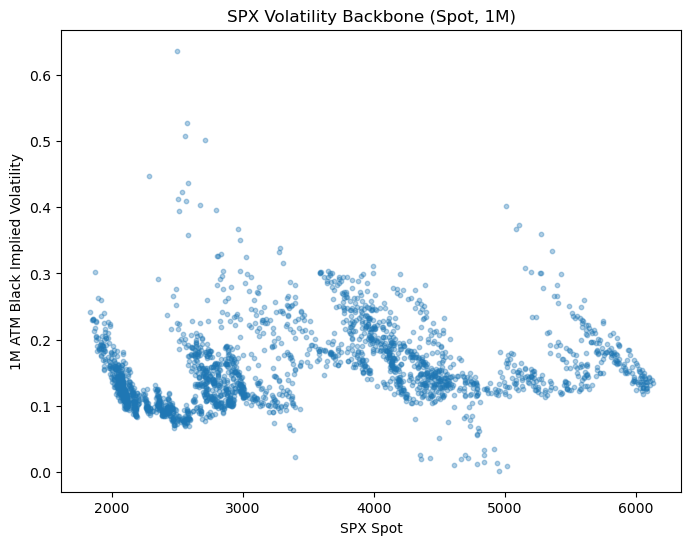

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(iv1m_df["spot"], iv1m_df["atm_iv_1m"], s=10, alpha=0.35)
plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Black Implied Volatility")
plt.title("SPX Volatility Backbone (Spot, 1M)")
plt.show()

In [44]:
print(iv1m_df.describe())
print("Correlation:", iv1m_df["spot"].corr(iv1m_df["atm_iv_1m"]))

                            datetime         spot    atm_iv_1m
count                           2405  2405.000000  2405.000000
mean   2020-02-29 06:51:16.465696512  3431.355948     0.154027
min              2015-01-02 16:15:00  1830.860000     0.001658
25%              2017-07-24 16:15:00  2438.080000     0.115787
50%              2020-02-13 16:15:00  3071.145000     0.141855
75%              2022-10-21 16:15:00  4298.895000     0.180905
max              2025-05-13 16:15:00  6132.630000     0.636744
std                              NaN  1158.115959     0.056819
Correlation: 0.20353946635296713


##### By Year

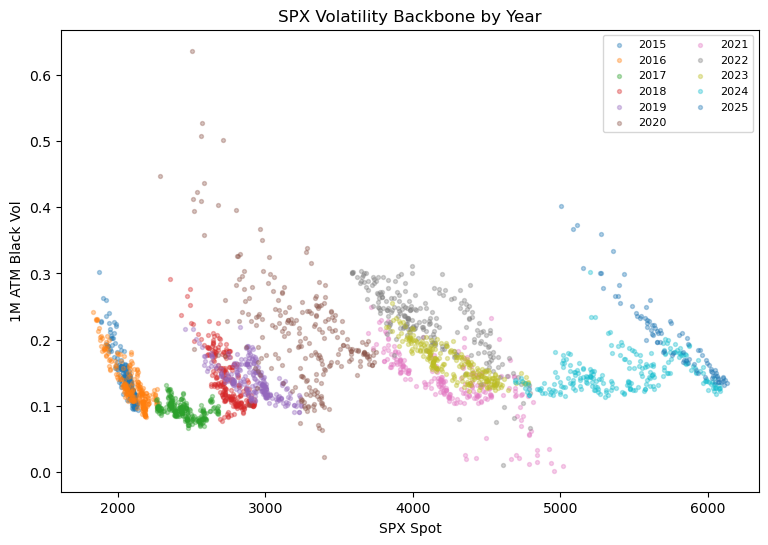

In [48]:
iv1m_df["year"] = iv1m_df["datetime"].dt.year

plt.figure(figsize=(9, 6))

for y, g in iv1m_df.groupby("year"):
    plt.scatter(g["spot"], g["atm_iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Black Vol")
plt.title("SPX Volatility Backbone by Year")
plt.legend(ncol=2, fontsize=8)
plt.show()

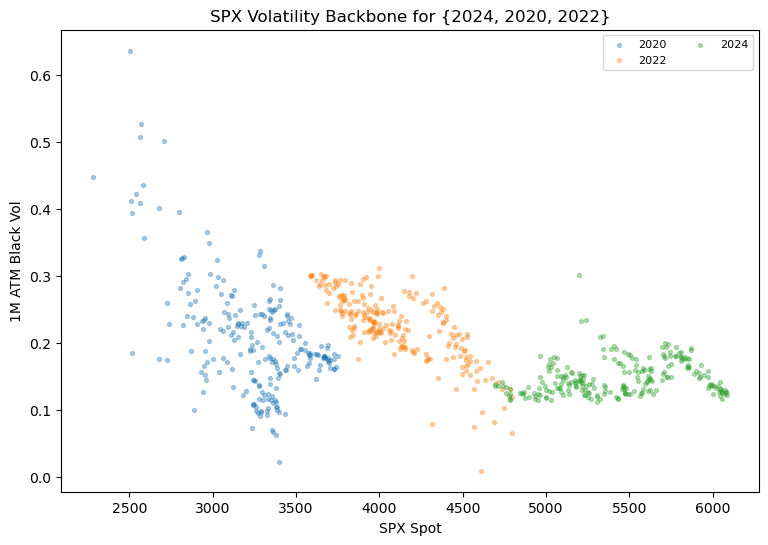

In [50]:
plt.figure(figsize=(9, 6))

target_years = {2020, 2022, 2024} # Using a set is faster for lookups

for y, g in iv1m_df.groupby("year"):
    if y not in target_years:
        continue
    plt.scatter(g["spot"], g["atm_iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Black Vol")
plt.title(f"SPX Volatility Backbone for {target_years}")
plt.legend(ncol=2, fontsize=8)
plt.show()




##### Δvol vs Δlog spot

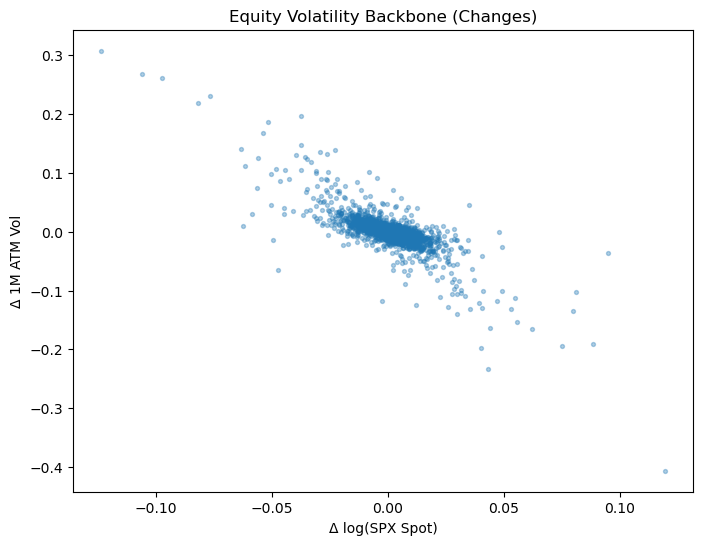

In [56]:
iv1m_df = iv1m_df.sort_values("datetime")

iv1m_df["d_iv"] = iv1m_df["atm_iv_1m"].diff()
iv1m_df["d_log_spot"] = np.log(iv1m_df["spot"]).diff()

chg = iv1m_df.dropna()

plt.figure(figsize=(8, 6))
plt.scatter(chg["d_log_spot"], chg["d_iv"], s=8, alpha=0.35)
plt.xlabel("Δ log(SPX Spot)")
plt.ylabel("Δ 1M ATM Vol")
plt.title("Equity Volatility Backbone (Changes)")
plt.show()

In [273]:
# Sort the values by the x-axis (d_log_spot) so the LOWESS curve plots correctly
chg_sorted = chg.sort_values("d_log_spot")

# Fit the LOWESS curve (frac controls the smoothing window, 0.2 is a solid baseline)
smoothed = lowess(chg_sorted["d_iv"], chg_sorted["d_log_spot"], frac=0.2)
lowess_x = smoothed[:, 0]
lowess_y = smoothed[:, 1]

# Calculate the 2nd differences (acceleration of spot and volatility)
iv1m_df["d2_iv"] = iv1m_df["d_iv"].diff()
iv1m_df["d2_log_spot"] = iv1m_df["d_log_spot"].diff()


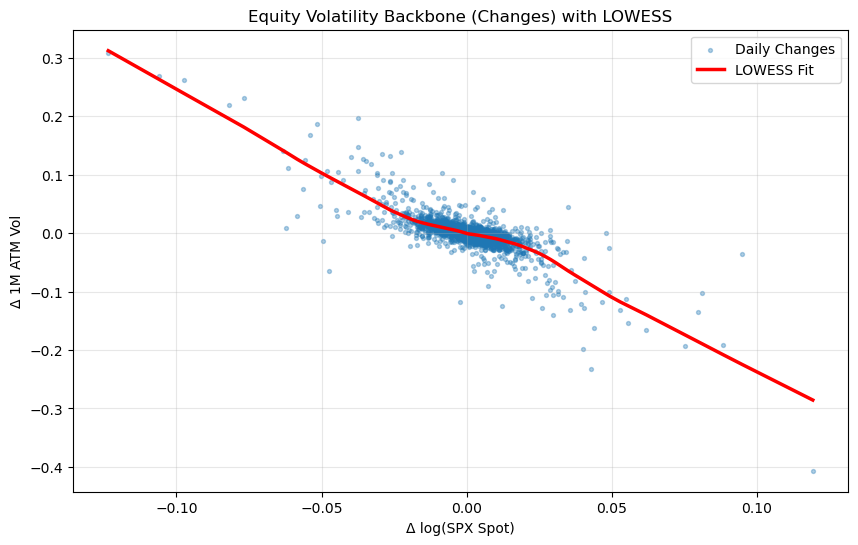

In [275]:
# Plot 1: Delta IV vs Delta Log Spot with LOWESS Fit

plt.figure(figsize=(10, 6))
plt.scatter(chg["d_log_spot"], chg["d_iv"], s=8, alpha=0.35, label="Daily Changes")
plt.plot(lowess_x, lowess_y, color='red', linewidth=2.5, label="LOWESS Fit")

plt.xlabel("Δ log(SPX Spot)")
plt.ylabel("Δ 1M ATM Vol")
plt.title("Equity Volatility Backbone (Changes) with LOWESS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

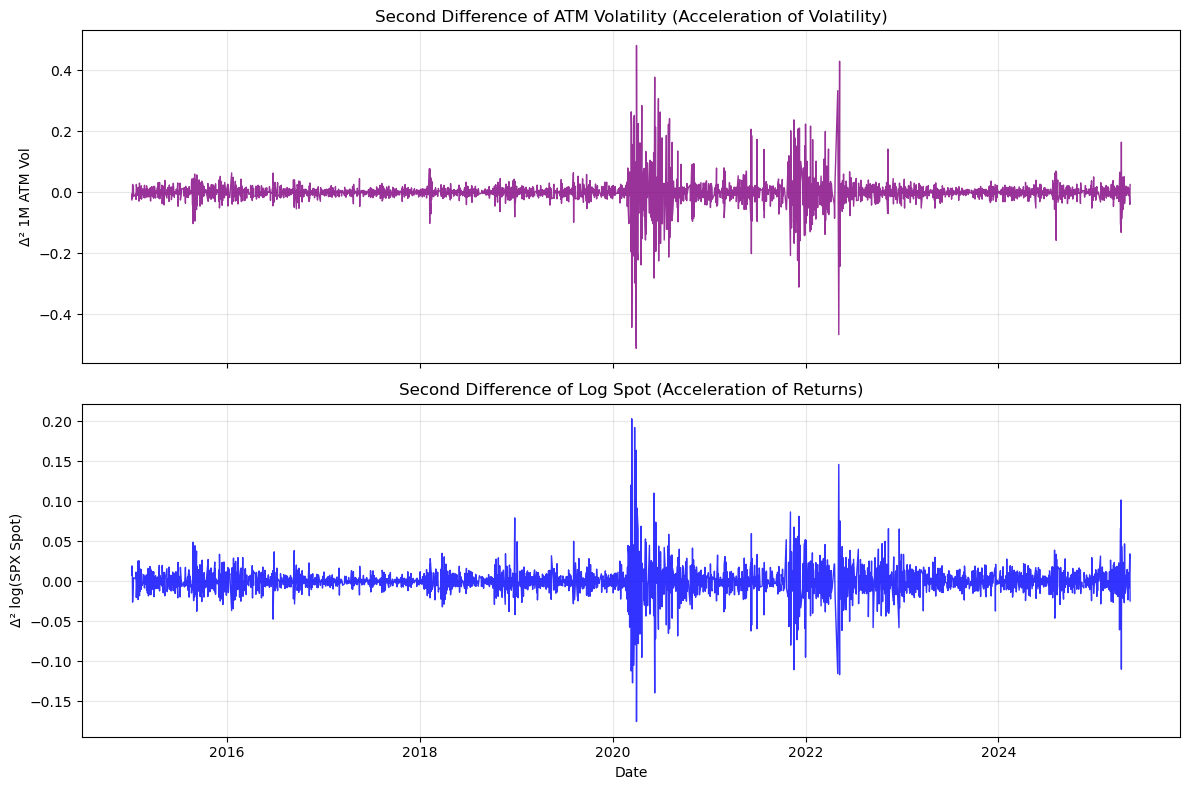

In [277]:
# Plot 2: Time Series of 2nd Differences

chg2 = iv1m_df.dropna(subset=["d2_iv", "d2_log_spot"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(chg2["datetime"], chg2["d2_iv"], color="purple", linewidth=1, alpha=0.8)
ax1.set_ylabel("Δ² 1M ATM Vol")
ax1.set_title("Second Difference of ATM Volatility (Acceleration of Volatility)")
ax1.grid(alpha=0.3)

ax2.plot(chg2["datetime"], chg2["d2_log_spot"], color="blue", linewidth=1, alpha=0.8)
ax2.set_ylabel("Δ² log(SPX Spot)")
ax2.set_xlabel("Date")
ax2.set_title("Second Difference of Log Spot (Acceleration of Returns)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Uncertain Vol ATM

In [13]:
import option_pricers as op

ModuleNotFoundError: No module named 'option_pricers'

In [ ]:
def regime(year):
    if year <= 2017:
        return "Low Vol (2015-17)"
    elif year <= 2019:
        return "Transition (2018-19)"
    elif year == 2020:
        return "COVID"
    else:
        return "Post-COVID"

iv1m_df["regime"] = iv1m_df["year"].apply(regime)

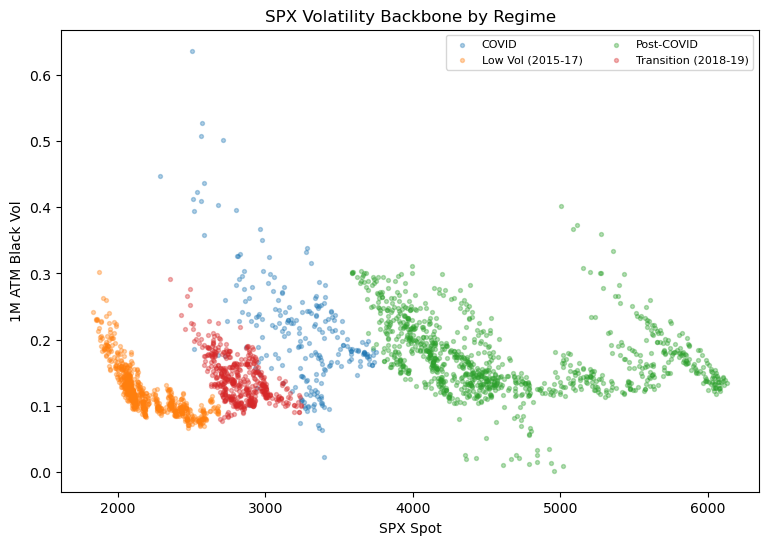

In [ ]:
plt.figure(figsize=(9, 6))

for y, g in iv1m_df.groupby("regime"):
    plt.scatter(g["spot"], g["atm_iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Black Vol")
plt.title("SPX Volatility Backbone by Regime")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [ ]:
def model_atm_vol(S, r, T, weights, betas, sigmas_ln):
    sigmas_n = np.array(sigmas_ln) * S
    
    prices = [
        op.DisplacedDiffusionCall(S, S, r, sigma_n, sigma_ln, beta, T)
        for sigma_n, sigma_ln, beta in zip(sigmas_n, sigmas_ln, betas)
    ]
    
    model_price = np.dot(weights, prices)
    
    return op.impliedVolatility(S, S, r, model_price, T, 'call')

#### Loss: MSE

In [ ]:
# loss mse
import numpy as np
from scipy.optimize import minimize

def loss(params, S_data, iv_data, r, T):
    weights = params[0:3]
    betas = params[3:6]
    sigmas_ln = params[6:9]
    
    # Softmax constraint to ensure weights sum to 1 smoothly
    weights = np.exp(weights) / np.sum(np.exp(weights))
    
    # Anchor the normal volatilities to a reference spot level 
    # to prevent the displacement from scaling linearly with every S.
    S_ref = np.mean(S_data)
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    
    # Prevent negative parameters from breaking the pricer
    if np.any(betas <= 0) or np.any(sigmas_ln <= 0):
        return 1e6
    
    model_ivs = [
        op.uncertain_backbone(S, S, r, T, weights, betas, sigmas_n, sigmas_ln)
        for S in S_data
    ]
    
    return np.mean((np.array(model_ivs) - np.array(iv_data))**2)

In [ ]:
iv1m_df.columns

Index(['Unnamed: 0', 'datetime', 'spot', 'atm_iv_1m', 'year', 'regime'], dtype='object')

##### by yr

In [ ]:
TARGET_TAU = 30 / 365

from scipy.optimize import minimize

fits = {}

for year, g in iv1m_df.groupby("year"):
    
    S_data = g["spot"].values
    iv_data = g["atm_iv_1m"].values   # or smoothed
    
    # Bounds: (min, max) for each parameter
    # weights (3), betas (3), sigmas_ln (3)
    # We bound betas away from 1.0, e.g., forcing them to be lower to induce skew
    bounds = [
        (None, None), (None, None), (None, None),  # weights (pre-softmax)
        (0.1, 0.95), (0.1, 0.95), (0.1, 0.95),     # betas bounded below 1
        (0.01, 2.0), (0.01, 2.0), (0.01, 2.0)      # sigmas_ln bounds
    ]
    
    res = minimize(
        loss,
        init,
        args=(S_data, iv_data, 0.02, TARGET_TAU),
        method="L-BFGS-B", # Switch to a bounded method
        bounds=bounds,
        options={"maxiter": 1000}
    )
    
    fits[year] = res.x

NameError: name 'init' is not defined

In [ ]:
betas

array([0.21482443, 0.16501607, 0.1       ])

In [ ]:
weights

array([0.1121437 , 0.11004445, 0.77781185])

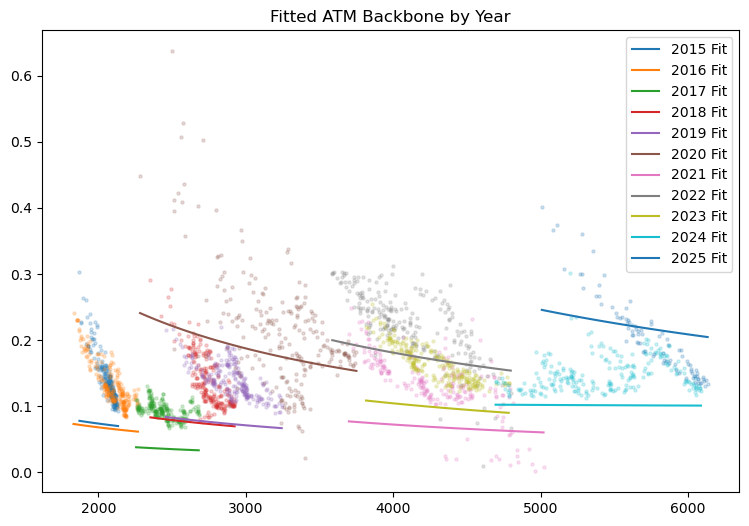

In [ ]:
plt.figure(figsize=(9, 6))

for year, g in iv1m_df.groupby("year"):
    
    params = fits[year]
    
    # NOTE: Ensure this matches EXACTLY how you transform weights in your loss function!
    # If your loss function used softmax ( np.exp(w) / np.sum(np.exp(w)) ), use that here instead.
    weights = np.abs(params[:3])
    weights /= weights.sum()
    
    betas = params[3:6]
    sigmas_ln = np.abs(params[6:9])
    
    # ---------------------------------------------------------
    # THE FIX: Anchor the normal volatilities to the mean spot 
    # of the current year BEFORE looping over S_grid
    # ---------------------------------------------------------
    S_ref = g["spot"].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    
    S_grid = np.linspace(g["spot"].min(), g["spot"].max(), 100)
    
    # Call uncertain_backbone directly and pass the fixed sigmas_n
    fitted = [
        op.uncertain_backbone(S, S, 0.0, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
        for S in S_grid
    ]
    
    plt.scatter(g["spot"], g["atm_iv_1m"], s=5, alpha=0.2)
    plt.plot(S_grid, fitted, label=f"{year} Fit")

plt.legend()
plt.title("Fitted ATM Backbone by Year")
plt.show()

##### by regime

In [ ]:
# by regime
iv1m_df["year"] = pd.to_datetime(iv1m_df["datetime"]).dt.year
iv1m_df["regime"] = iv1m_df["year"].apply(regime)

fits_reg = {}

for regime_name, g in iv1m_df.groupby("regime"):
    
    S_data = g["spot"].values
    iv_data = g["atm_iv_1m"].values

    # initial guess
    init = np.array([
        0.3, 0.3, 0.4,   # weights
        1.0, 1.1, 1.2,   # betas
        0.2, 0.5, 1.0    # sigmas_ln
    ])
    
    # Bounds: (min, max) for each parameter
    # weights (3), betas (3), sigmas_ln (3)
    # We bound betas away from 1.0, e.g., forcing them to be lower to induce skew
    bounds = [
        (None, None), (None, None), (None, None),  # weights (pre-softmax)
        (0.1, 0.95), (0.1, 0.95), (0.1, 0.95),     # betas bounded below 1
        (0.01, 2.0), (0.01, 2.0), (0.01, 2.0)      # sigmas_ln bounds
    ]
    
    res = minimize(
        loss,
        init,
        args=(S_data, iv_data, 0.02, TARGET_TAU),
        method="L-BFGS-B", # Switch to a bounded method
        bounds=bounds,
        options={"maxiter": 1000}
    )
    
    fits_reg[regime_name] = res.x

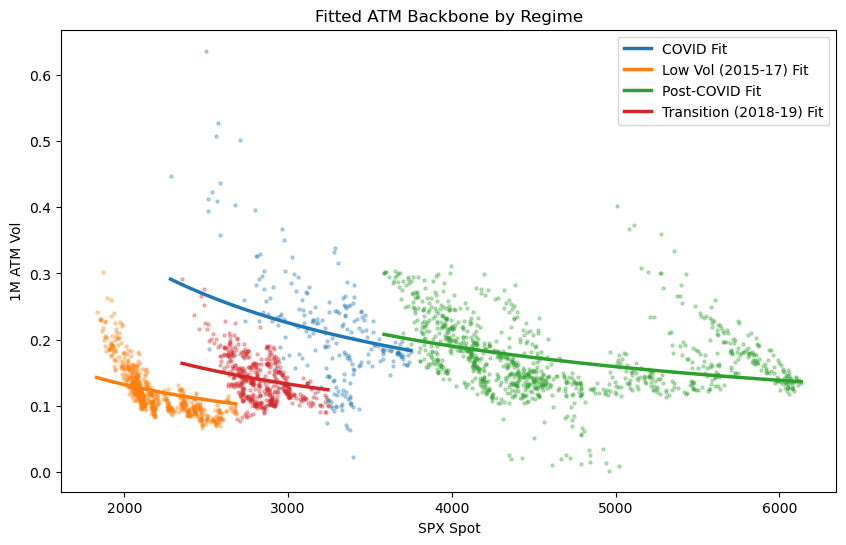

In [ ]:
plt.figure(figsize=(10, 6))

for reg, g in iv1m_df.groupby("regime"):
    
    params = fits_reg[reg]
    
    raw_weights = params[:3]
    weights_reg = np.exp(raw_weights) / np.sum(np.exp(raw_weights))
    
    betas_reg = params[3:6]
    sigmas_ln = np.abs(params[6:9]) # L-BFGS-B handles bounds, but abs is a safe catch
    
    # Anchor the normal volatilities to the mean spot of the current regime
    S_ref = g["spot"].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    
    S_grid = np.linspace(g["spot"].min(), g["spot"].max(), 100)
    
    # Call uncertain_backbone directly with the fixed sigmas_n
    fitted = [
        op.uncertain_backbone(S, S, 0.02, TARGET_TAU, weights_reg, betas_reg, sigmas_n, sigmas_ln)
        for S in S_grid
    ]
    
    plt.scatter(g["spot"], g["atm_iv_1m"], s=5, alpha=0.3)
    plt.plot(S_grid, fitted, label=f"{reg} Fit", linewidth=2.5)

plt.legend()
plt.title("Fitted ATM Backbone by Regime")
plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Vol")
plt.show()

In [ ]:
weights_reg

array([0.38391127, 0.33820459, 0.27788415])

In [ ]:
betas_reg

array([0.88265254, 0.89017765, 0.1       ])

#### Loss: MAE

In [ ]:
def loss_mae(params, S_data, iv_data, r, T):
    weights = params[0:3]
    betas = params[3:6]
    sigmas_ln = params[6:9]
    
    # Softmax constraint to ensure weights sum to 1 smoothly
    weights = np.exp(weights) / np.sum(np.exp(weights))
    
    # Anchor the normal volatilities to a reference spot level 
    S_ref = np.mean(S_data)
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    
    # Prevent negative parameters from breaking the pricer
    if np.any(betas <= 0) or np.any(sigmas_ln <= 0):
        return 1e6
    
    model_ivs = [
        op.uncertain_backbone(S, S, r, T, weights, betas, sigmas_n, sigmas_ln)
        for S in S_data
    ]
    
    return np.mean(np.abs(np.array(model_ivs) - np.array(iv_data)))

In [ ]:
# by regime
iv1m_df["year"] = pd.to_datetime(iv1m_df["datetime"]).dt.year
iv1m_df["regime"] = iv1m_df["year"].apply(regime)

fits_reg = {}

for regime_name, g in iv1m_df.groupby("regime"):
    
    S_data = g["spot"].values
    iv_data = g["atm_iv_1m"].values

    # initial guess
    init = np.array([
        0.3, 0.3, 0.4,   # weights
        1.0, 1.1, 1.2,   # betas
        0.2, 0.5, 1.0    # sigmas_ln
    ])
    
    # Bounds: (min, max) for each parameter
    # weights (3), betas (3), sigmas_ln (3)
    # We bound betas away from 1.0, e.g., forcing them to be lower to induce skew
    bounds = [
        (None, None), (None, None), (None, None),  # weights (pre-softmax)
        (0.1, 0.95), (0.1, 0.95), (0.1, 0.95),     # betas bounded below 1
        (0.01, 2.0), (0.01, 2.0), (0.01, 2.0)      # sigmas_ln bounds
    ]
    
    res = minimize(
        loss_mae,
        init,
        args=(S_data, iv_data, 0.02, TARGET_TAU),
        method="L-BFGS-B", # Switch to a bounded method
        bounds=bounds,
        options={"maxiter": 1000}
    )
    
    fits_reg[regime_name] = res.x

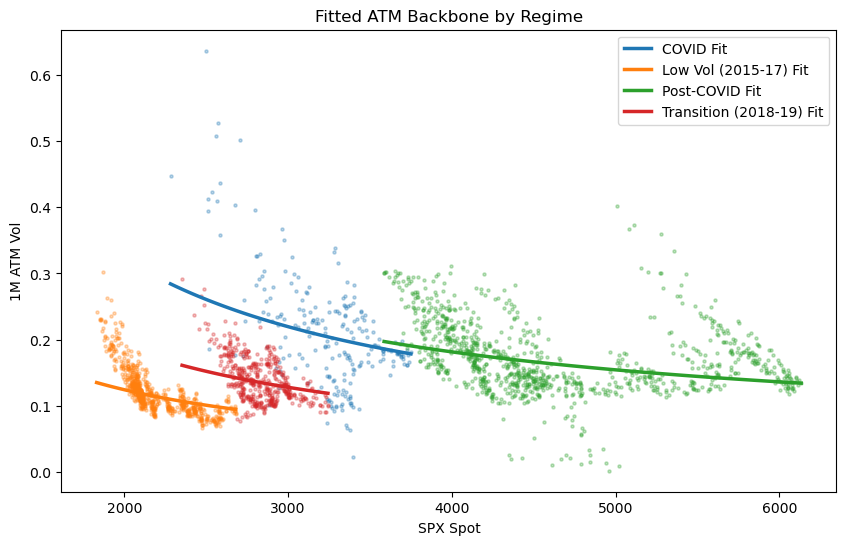

In [ ]:
plt.figure(figsize=(10, 6))

for reg, g in iv1m_df.groupby("regime"):
    
    params = fits_reg[reg]
    
    raw_weights = params[:3]
    weights_reg = np.exp(raw_weights) / np.sum(np.exp(raw_weights))
    
    betas_reg = params[3:6]
    sigmas_ln = np.abs(params[6:9]) # L-BFGS-B handles bounds, but abs is a safe catch
    
    # Anchor the normal volatilities to the mean spot of the current regime
    S_ref = g["spot"].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    
    S_grid = np.linspace(g["spot"].min(), g["spot"].max(), 100)
    
    # Call uncertain_backbone directly with the fixed sigmas_n
    fitted = [
        op.uncertain_backbone(S, S, 0.02, TARGET_TAU, weights_reg, betas_reg, sigmas_n, sigmas_ln)
        for S in S_grid
    ]
    
    plt.scatter(g["spot"], g["atm_iv_1m"], s=5, alpha=0.3)
    plt.plot(S_grid, fitted, label=f"{reg} Fit", linewidth=2.5)

plt.legend()
plt.title("Fitted ATM Backbone by Regime")
plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Vol")
plt.show()

In [ ]:
weights_reg

array([0.32960718, 0.36020758, 0.31018524])

In [ ]:
betas_reg

array([0.10260291, 0.10000021, 0.1       ])

#### Uncertain vol smile & backbone

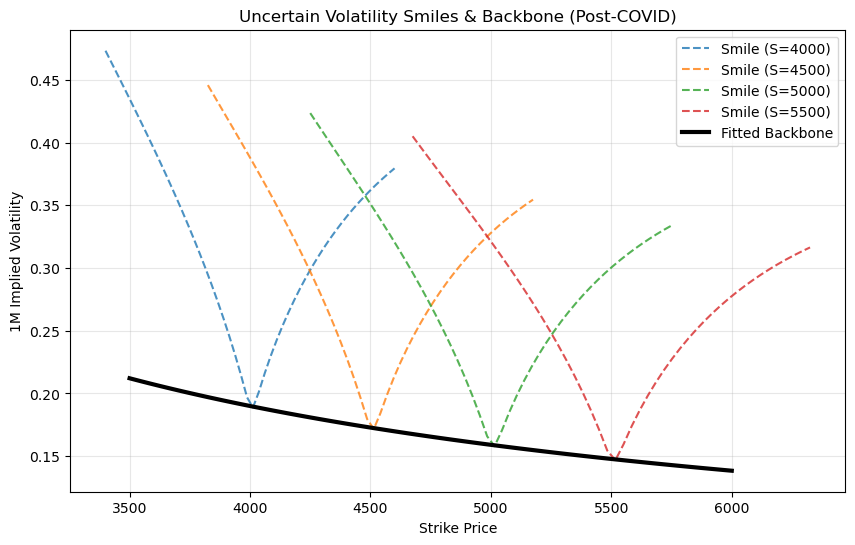

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the fitted parameters for a specific regime
reg = "Post-COVID"
g = iv1m_df[iv1m_df["regime"] == reg]
params = fits_reg[reg]

# Apply the same transformations used in the loss function
raw_weights = params[:3]
weights = np.exp(raw_weights) / np.sum(np.exp(raw_weights))
betas = params[3:6]
sigmas_ln = np.abs(params[6:9])

# Anchor the normal vol to the mean spot of regime
S_ref = g["spot"].mean()
sigmas_n = list(np.array(sigmas_ln) * S_ref)

# 2. Pick a few representative spot prices from this regime to draw smiles
spots_to_plot = [4000, 4500, 5000, 5500] 

plt.figure(figsize=(10, 6))

# 3. Plot the Vol Smiles (Dashed Lines)
for S in spots_to_plot:
    # Create a strike grid +/- 15% around the current spot price
    K_grid = np.linspace(S * 0.85, S * 1.15, 50)
    
    # Calculate the full smile across strikes
    smile = [
        op.uncertain_backbone(S, K, 0.02, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
        for K in K_grid
    ]
    plt.plot(K_grid, smile, linestyle='--', alpha=0.8, label=f'Smile (S={S})')

# 4. Plot the Backbone (Solid Line)
# Create a continuous spot grid to draw the smooth backbone
S_grid = np.linspace(3500, 6000, 100)

backbone = [
    # Notice we pass S for both Spot and Strike to isolate the ATM backbone
    op.uncertain_backbone(S, S, 0.02, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
    for S in S_grid
]

# Plot the backbone as a thick solid line
plt.plot(S_grid, backbone, color='black', linewidth=3, label='Fitted Backbone')

plt.xlabel("Strike Price")
plt.ylabel("1M Implied Volatility")
plt.title(f"Uncertain Volatility Smiles & Backbone ({reg})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Vol Backbone by log($)

### log($)

In [102]:
%who

DATA_DIR	 TARGET_KS	 TARGET_LM_CALL	 TARGET_LM_PUT	 TARGET_TAU	 USFederalHolidayCalendar	 all_dfs	 atm_df	 atm_list	 
ax1	 ax2	 brentq	 bs_call_price	 chg	 chg2	 chg_sorted	 colors	 dataframe_columns	 
dataframe_hash	 date	 df	 dfs	 dtypes_str	 expiry	 expiry_pattern	 f	 f_smile	 
f_tau_call	 f_tau_put	 fig	 final_surface_df	 fname	 g	 get_dataframes	 getpass	 hashlib	 
implied_vol_call	 import_pandas_safely	 interp1d	 is_data_frame	 iv1m_df	 iv1m_k_df	 iv1m_otm_df	 iv_1m	 iv_1m_k	 
iv_1m_otm	 iv_call	 iv_k	 iv_put	 json	 k	 lowess	 lowess_x	 lowess_y	 
m_df	 match	 moneyness_list	 near	 norm	 np	 os	 otm10	 otm_df	 
otm_list	 pd	 plt	 q	 r	 re	 reg	 regime	 roll_expiry	 
smoothed	 target_years	 tmp	 total_var	 total_var_call	 total_var_put	 tv_1m	 tv_1m_call	 tv_1m_put	 
us_holidays	 x	 y	 


In [87]:
# Returns a list of variable names that are DataFrames
all_dfs = [var for var in dir() if isinstance(eval(var), pd.core.frame.DataFrame)]
all_dfs

['_21',
 '_30',
 '_35',
 '_39',
 '_6',
 'atm_df',
 'chg',
 'chg2',
 'chg_sorted',
 'df',
 'final_surface_df',
 'g',
 'iv1m_df',
 'iv1m_otm_df',
 'near',
 'otm_df',
 'tmp']

In [91]:
df.columns

Index(['datetime', 'strike', 'call_bid', 'call_ask', 'put_bid', 'put_ask',
       'underlying', 'expiry', 'source_file', 'call_impliedvol', 'call_delta',
       'call_gamma', 'call_vega', 'call_theta', 'put_impliedvol', 'put_delta',
       'put_gamma', 'put_vega', 'put_theta', 'call_mid', 'tau', 'iv',
       'log_moneyness'],
      dtype='object')

In [133]:
from scipy.interpolate import interp1d

TARGET_KS = [0.0, -0.10, -0.20, +0.10, +0.20]

moneyness_list = []

for (date, expiry), g in df.groupby(["datetime", "expiry"]):

    g = g.sort_values("log_moneyness")

    # remove NaNs
    g = g.dropna(subset=["log_moneyness", "iv"])

    # need enough strikes
    if len(g) < 4:
        continue

    x = g["log_moneyness"].values
    y = g["iv"].values

    try:

        f = interp1d(
            x,
            y,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate"
        )

        for k in TARGET_KS:

            iv_k = float(f(k))

            if np.isnan(iv_k) or iv_k <= 0:
                continue

            moneyness_list.append({
                "datetime": date,
                "expiry": expiry,
                "tau": g["tau"].iloc[0],
                "spot": g["underlying"].iloc[0],
                "k": k,
                "iv_k": iv_k
            })

    except:
        continue

m_df = pd.DataFrame(moneyness_list)

In [134]:
TARGET_TAU = 30 / 365

iv_1m_k = []

for (date, k), g in m_df.groupby(["datetime", "k"]):

    g = g.sort_values("tau")

    if g["tau"].min() > TARGET_TAU or g["tau"].max() < TARGET_TAU:
        continue

    total_var = g["iv_k"]**2 * g["tau"]

    try:

        f = interp1d(
            g["tau"],
            total_var,
            kind="linear"
        )

        tv_1m = float(f(TARGET_TAU))

        if np.isnan(tv_1m) or tv_1m <= 0:
            continue

        iv_1m_k.append({
            "datetime": date,
            "spot": g["spot"].iloc[0],
            "k": k,
            "iv_1m": np.sqrt(tv_1m / TARGET_TAU)
        })

    except:
        continue

iv1m_k_df = pd.DataFrame(iv_1m_k)

In [135]:
iv1m_k_df["year"] = iv1m_k_df["datetime"].dt.year

In [136]:
iv1m_k_df["regime"] = iv1m_k_df["year"].apply(regime)

In [137]:
iv1m_k_df.columns

Index(['datetime', 'spot', 'k', 'iv_1m', 'year', 'regime'], dtype='object')

### Plots

#### ATM_k

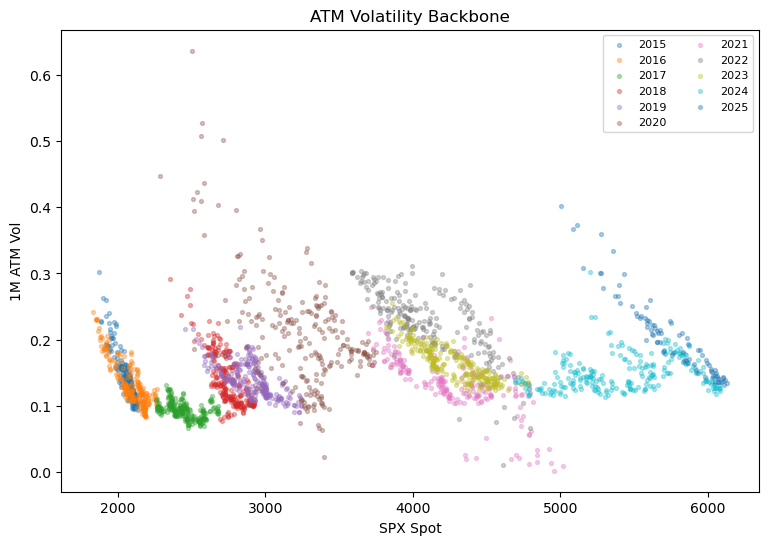

In [106]:
atm = iv1m_k_df[iv1m_k_df["k"] == 0.0]

plt.figure(figsize=(9,6))

for y, g in atm.groupby("year"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Vol")
plt.title("ATM Volatility Backbone")
plt.legend(ncol=2, fontsize=8)
plt.show()

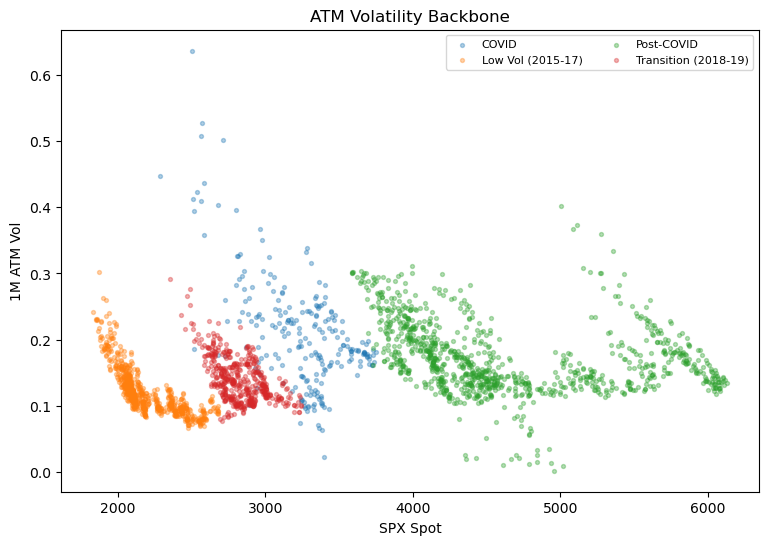

In [120]:
atm = iv1m_k_df[iv1m_k_df["k"] == 0.0]

plt.figure(figsize=(9,6))

for y, g in atm.groupby("regime"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M ATM Vol")
plt.title("ATM Volatility Backbone")
plt.legend(ncol=2, fontsize=8)
plt.show()

#### OTM-10_k

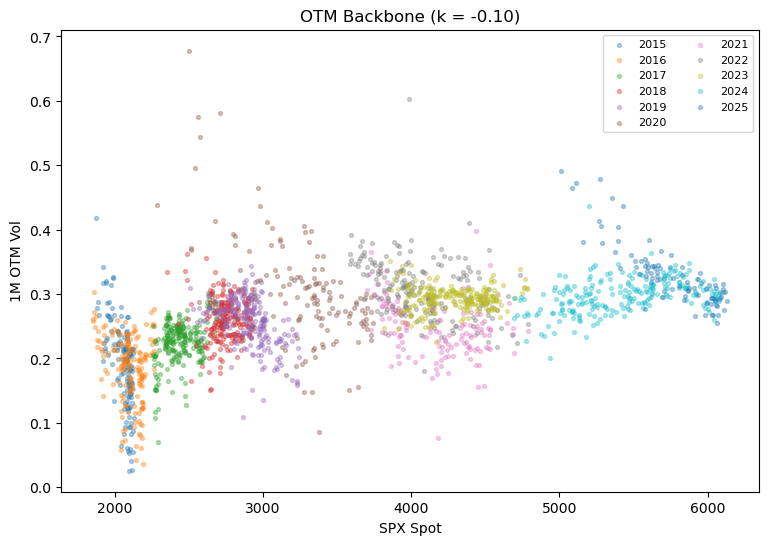

In [100]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == -0.10]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("year"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = -0.10)")
plt.legend(ncol=2, fontsize=8)
plt.show()

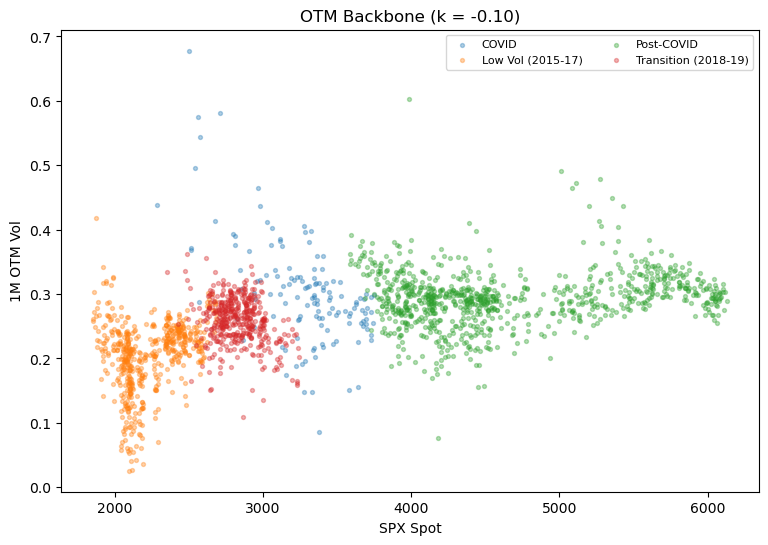

In [116]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == -0.10]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("regime"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = -0.10)")
plt.legend(ncol=2, fontsize=8)
plt.show()

#### OTM+10_k

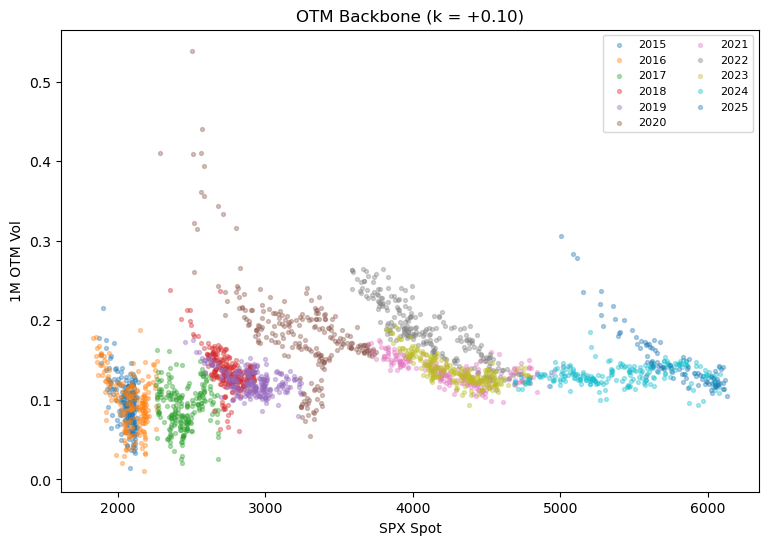

In [147]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == +0.10]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("year"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = +0.10)")
plt.legend(ncol=2, fontsize=8)
plt.show()

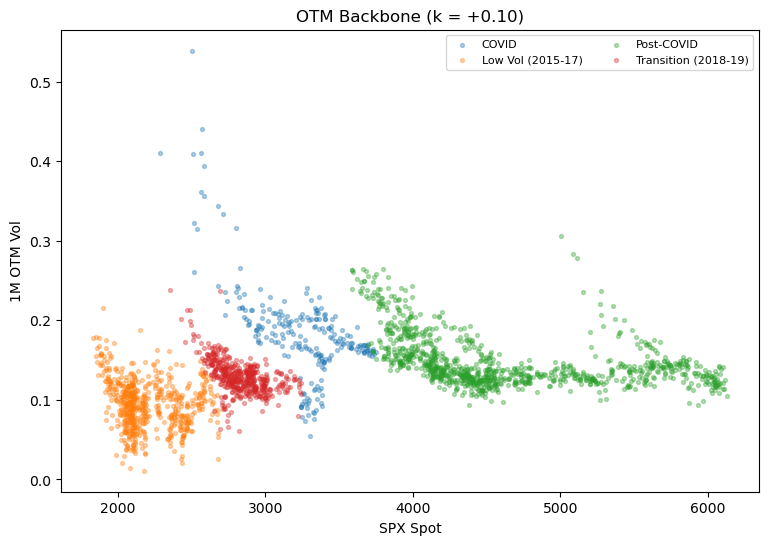

In [148]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == +0.10]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("regime"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = +0.10)")
plt.legend(ncol=2, fontsize=8)
plt.show()

#### OTM-20_k

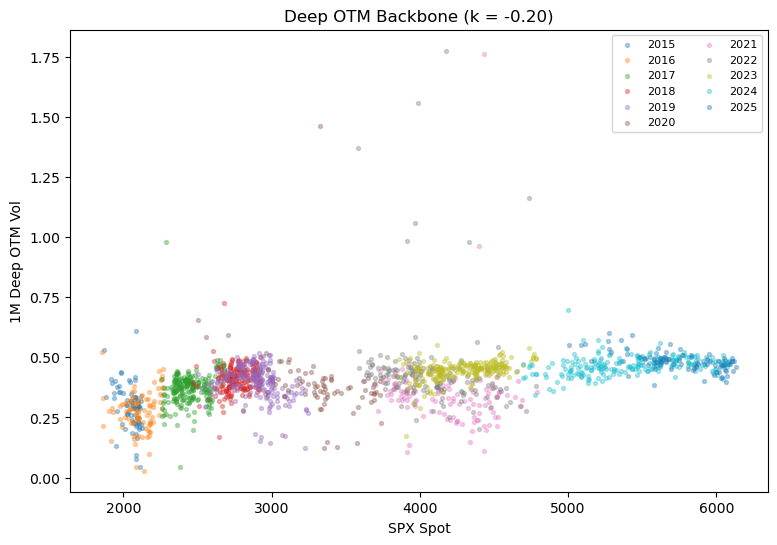

In [108]:
otm20 = iv1m_k_df[iv1m_k_df["k"] == -0.20]

plt.figure(figsize=(9,6))

for y, g in otm20.groupby("year"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M Deep OTM Vol")
plt.title("Deep OTM Backbone (k = -0.20)")
plt.legend(ncol=2, fontsize=8)
plt.show()

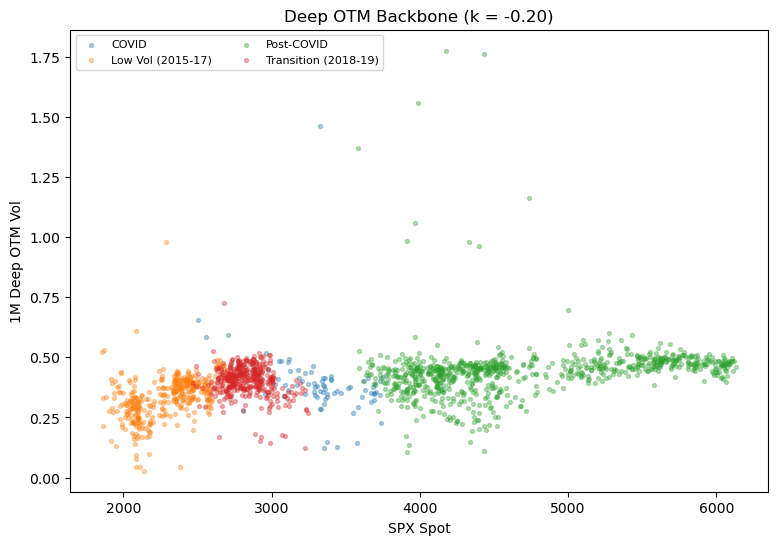

In [118]:
otm20 = iv1m_k_df[iv1m_k_df["k"] == -0.20]

plt.figure(figsize=(9,6))

for y, g in otm20.groupby("regime"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M Deep OTM Vol")
plt.title("Deep OTM Backbone (k = -0.20)")
plt.legend(ncol=2, fontsize=8)
plt.show()

#### OTM+20_k

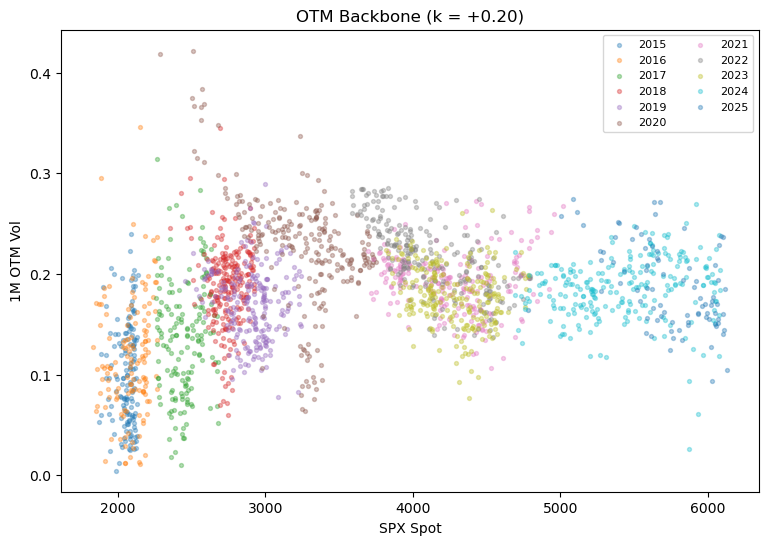

In [153]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == +0.20]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("year"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = +0.20)")
plt.legend(ncol=2, fontsize=8)
plt.show()

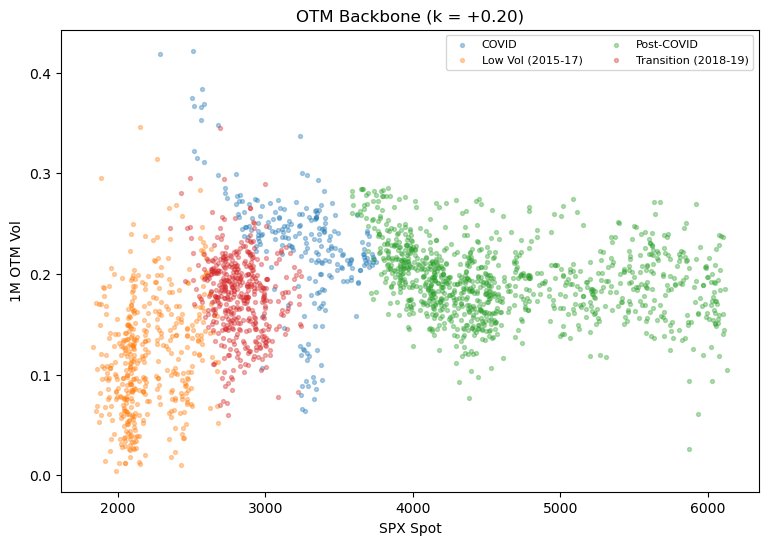

In [154]:
otm10 = iv1m_k_df[iv1m_k_df["k"] == +0.20]

plt.figure(figsize=(9,6))

for y, g in otm10.groupby("regime"):
    plt.scatter(g["spot"], g["iv_1m"], s=8, alpha=0.35, label=y)

plt.xlabel("SPX Spot")
plt.ylabel("1M OTM Vol")
plt.title("OTM Backbone (k = +0.20)")
plt.legend(ncol=2, fontsize=8)
plt.show()

#### Extra Plots

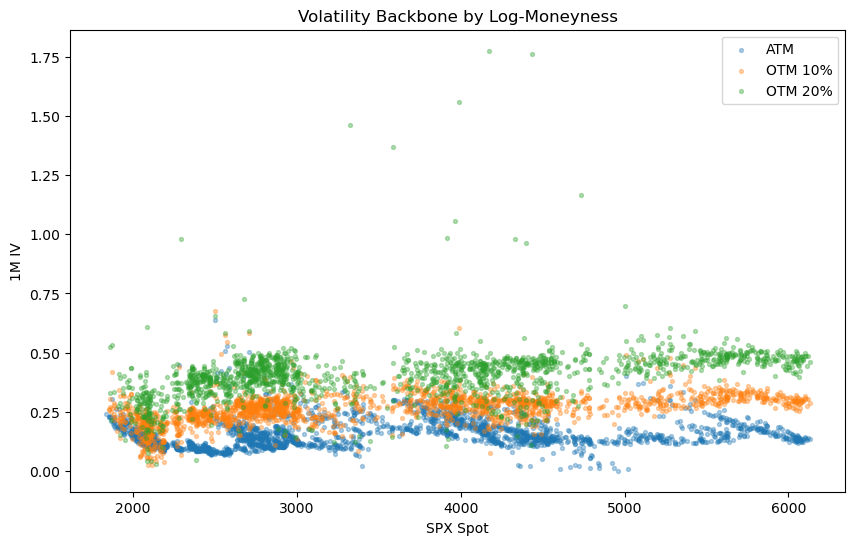

In [110]:
plt.figure(figsize=(10,6))

for k, label in [
    (0.0, "ATM"),
    (-0.10, "OTM 10%"),
    (-0.20, "OTM 20%")
]:

    g = iv1m_k_df[iv1m_k_df["k"] == k]

    plt.scatter(
        g["spot"],
        g["iv_1m"],
        s=8,
        alpha=0.35,
        label=label
    )

plt.xlabel("SPX Spot")
plt.ylabel("1M IV")
plt.title("Volatility Backbone by Log-Moneyness")
plt.legend()
plt.show()

In [122]:
# Pivot the dataframe so that each 'k' becomes its own column
# This allows us to easily subtract ATM (0.0) from OTM (-0.10, -0.20)
surf_wide = iv1m_k_df.pivot(index=["datetime", "spot"], columns="k", values="iv_1m").reset_index()

# Map the year and regime
surf_wide["year"] = pd.to_datetime(surf_wide["datetime"]).dt.year
surf_wide["regime"] = surf_wide["year"].apply(regime)

# Calculate the Skew spreads (Panic Premium)
surf_wide["skew_10_down"] = surf_wide[-0.10] - surf_wide[0.0]
surf_wide["skew_20_down"] = surf_wide[-0.20] - surf_wide[0.0]

# Drop any rows where we couldn't calculate the spread
surf_wide = surf_wide.dropna(subset=["skew_10_down", "skew_20_down"])

# Define consistent regime colors
colors = {"Low Vol (2015-17)": "blue", 
          "Transition (2018-19)": "green", 
          "COVID": "red", 
          "Post-COVID": "purple"}

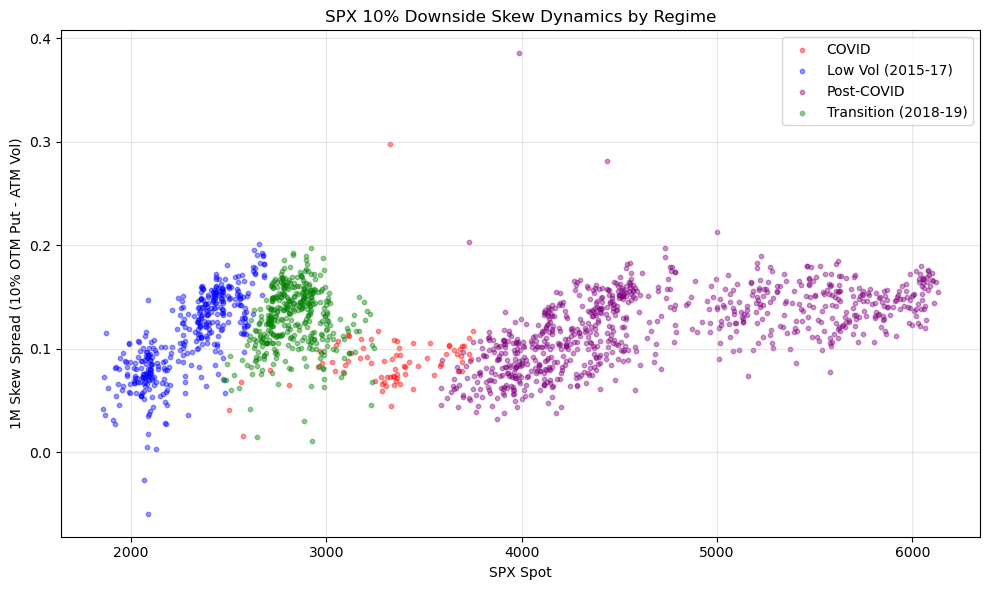

In [124]:
plt.figure(figsize=(10, 6))

for reg, g in surf_wide.groupby("regime"):
    plt.scatter(g["spot"], g["skew_10_down"], s=10, alpha=0.4, label=reg, color=colors.get(reg))

plt.xlabel("SPX Spot")
plt.ylabel("1M Skew Spread (10% OTM Put - ATM Vol)")
plt.title("SPX 10% Downside Skew Dynamics by Regime")
plt.legend(fontsize=10, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

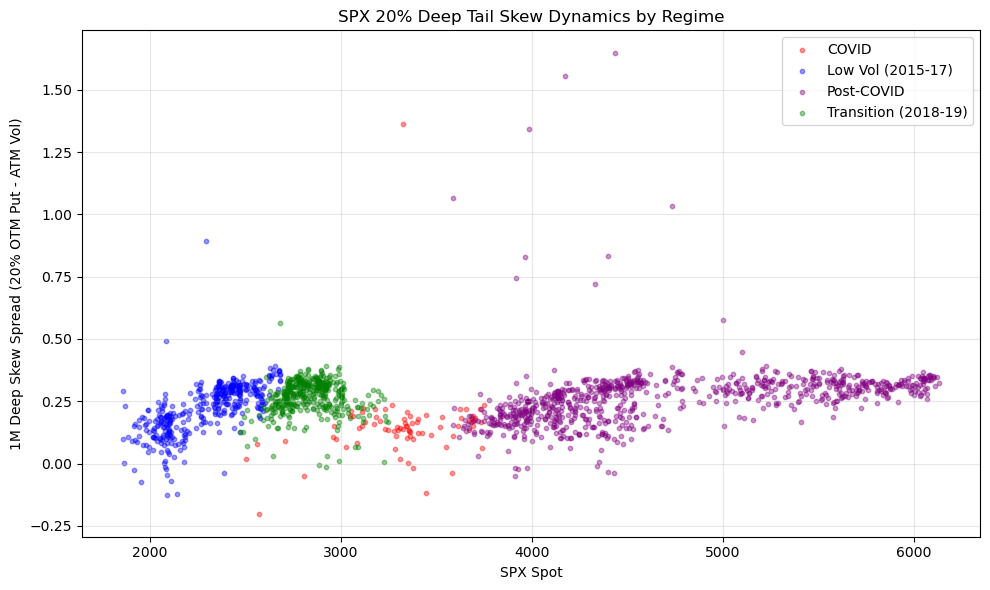

In [126]:
plt.figure(figsize=(10, 6))

for reg, g in surf_wide.groupby("regime"):
    plt.scatter(g["spot"], g["skew_20_down"], s=10, alpha=0.4, label=reg, color=colors.get(reg))

plt.xlabel("SPX Spot")
plt.ylabel("1M Deep Skew Spread (20% OTM Put - ATM Vol)")
plt.title("SPX 20% Deep Tail Skew Dynamics by Regime")
plt.legend(fontsize=10, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Next steps
Explore affect of Moneyness



## Importing saved CSVs

In [3]:
df = pd.read_csv("./processed_data/df.csv")
iv1m_df = pd.read_csv("./processed_data/1M_ATM.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'datetime', 'strike', 'call_bid', 'call_ask', 'put_bid',
       'put_ask', 'underlying', 'expiry', 'source_file', 'call_impliedvol',
       'call_delta', 'call_gamma', 'call_vega', 'call_theta', 'put_impliedvol',
       'put_delta', 'put_gamma', 'put_vega', 'put_theta', 'call_mid', 'tau',
       'iv', 'log_moneyness'],
      dtype='str')

In [4]:
iv1m_df.head()

,Unnamed: 0,datetime,spot,atm_iv_1m,year
0,0,2015-01-02 16:15:00,2055.050,0.131261,2015
1,1,2015-01-05 16:15:00,2021.700,0.157472,2015
2,2,2015-01-06 16:15:00,2004.165,0.158880,2015
3,3,2015-01-07 16:15:00,2025.225,0.155366,2015
4,4,2015-01-08 16:15:00,2061.885,0.131166,2015


In [5]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'].dt.year.unique()

array([2015, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024, 2025, 2019],
      dtype=int32)

In [6]:
iv1m_df['datetime'] = pd.to_datetime(iv1m_df['datetime'])

In [ ]:
strike_counts = (
    df.groupby(["datetime","strike"])["tau"]
    .nunique()
)

print(strike_counts.describe())

count    660933.000000
mean          2.351350
std           0.760916
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: tau, dtype: float64


In [ ]:
print("Median:", strike_counts.median())

Median: 3.0


In [ ]:
check = []

for (dt, tau), g in df.groupby(["datetime","tau"]):

    deltas = g["put_delta"].dropna().values

    if len(deltas) == 0:
        continue   # skip empty groups

    has_25 = (deltas.min() <= -0.25) and (deltas.max() >= -0.25)
    has_5  = (deltas.min() <= -0.05) and (deltas.max() >= -0.05)

    check.append({
        "has_25": has_25,
        "has_5": has_5
    })

check_df = pd.DataFrame(check)

print(check_df.mean())

has_25    0.952475
has_5     0.773267
dtype: float64


In [ ]:
before = delta_surface.groupby(["datetime","delta_bucket"])["tau"].nunique()
after = (
    delta_surface
    .dropna(subset=["variance"])
    .groupby(["datetime","delta_bucket"])["tau"]
    .nunique()
)

print("Before cleaning:")
print(before.describe())

print("\nAfter cleaning:")
print(after.describe())

Before cleaning:
count    708.000000
mean       2.850282
std        0.364883
min        1.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: tau, dtype: float64

After cleaning:
count    708.000000
mean       2.850282
std        0.364883
min        1.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: tau, dtype: float64


In [ ]:
drop_tau = 0
drop_nan = 0
total = 0

for (dt, delta), g in delta_surface.groupby(["datetime","delta_bucket"]):

    total += 1

    g = g.sort_values("tau")
    g = g.dropna(subset=["tau", "variance"])

    if g["tau"].nunique() < 2:
        drop_tau += 1
        continue

    taus = g["tau"].values
    total_var = g["variance"].values

    try:
        f = interp1d(
            taus,
            total_var,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate"
        )

        tv_1m = float(f(TARGET_TAU))

        if np.isnan(tv_1m) or tv_1m <= 0:
            drop_nan += 1
            continue

    except:
        drop_nan += 1
        continue

print("Total groups:", total)
print("Dropped (tau issue):", drop_tau)
print("Dropped (bad var):", drop_nan)

Total groups: 708
Dropped (tau issue): 2
Dropped (bad var): 0


In [ ]:
fail_25 = 0
fail_5 = 0
total = 0

for (dt, tau), group in df.groupby(["datetime", "tau"]):

    total += 1

    iv_25 = interp_iv_at_delta(group, -0.25)
    iv_5  = interp_iv_at_delta(group, -0.05)

    if np.isnan(iv_25):
        fail_25 += 1
    if np.isnan(iv_5):
        fail_5 += 1

print("Total:", total)
print("25D failures:", fail_25)
print("5D failures:", fail_5)

Total: 7500
25D failures: 6491
5D failures: 6493


## Exporting files

In [238]:
# df.to_csv("D:/Research_data/df.csv")

# iv1m_df.to_csv("D:/Research_data/1M_ATM.csv")
# iv1m_delta_1.to_csv("D:/Research_data/1M_OTM.csv")

## OTM

### Setup

In [29]:
# ---------------------------------------------------------
# Self-Contained Setup for OTM Analysis
# ---------------------------------------------------------
# Run this cell (and the CSV import cells before it) to ensure
# all functions and imports are available for the new analysis.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
from scipy.interpolate import interp1d
import option_pricers as op
import importlib
importlib.reload(op)
import os
import pickle

# --- Regime classifier ---
def regime(year):
    if year <= 2017:
        return 'Low Vol (2015-17)'
    elif year <= 2019:
        return 'Transition (2018-19)'
    elif year == 2020:
        return 'COVID'
    else:
        return 'Post-COVID'

# --- MSE Loss for uncertain vol fitting ---
def loss(params, S_data, iv_data, r, T):
    weights = params[0:3]
    betas = params[3:6]
    sigmas_ln = params[6:9]
    weights = np.exp(weights) / np.sum(np.exp(weights))
    S_ref = np.mean(S_data)
    sigmas_n = list(np.array(sigmas_ln) * S_ref)
    if np.any(betas <= 0) or np.any(sigmas_ln <= 0):
        return 1e6
    model_ivs = [
        op.uncertain_backbone(S, S, r, T, weights, betas, sigmas_n, sigmas_ln)
        for S in S_data
    ]
    return np.mean((np.array(model_ivs) - np.array(iv_data))**2)

# --- BS Put pricer ---
def bs_put_price(S, K, r, q, T, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def implied_vol_put(price, S, K, r, q, T):
    if price <= 0 or T <= 0:
        return np.nan
    intrinsic = max(K * np.exp(-r * T) - S * np.exp(-q * T), 0)
    upper = K * np.exp(-r * T)
    if price < intrinsic or price > upper:
        return np.nan
    try:
        return brentq(
            lambda sigma: bs_put_price(S, K, r, q, T, sigma) - price,
            1e-6, 5.0
        )
    except:
        return np.nan

# --- Ensure datetime columns are parsed ---
df['datetime'] = pd.to_datetime(df['datetime'])
iv1m_df['datetime'] = pd.to_datetime(iv1m_df['datetime'])

# --- Reload regime fits if previously saved ---
fits_path = './processed_data/fits_regime_mse.pkl'
if os.path.exists(fits_path):
    with open(fits_path, 'rb') as f:
        fits_regime_mse = pickle.load(f)
    print(f'Loaded saved fits from: {fits_path}')
else:
    fits_regime_mse = None
    print('No saved fits found — will re-fit in next cells.')


# --- Add regime column to iv1m_df ---
if 'year' in iv1m_df.columns and 'regime' not in iv1m_df.columns:
    iv1m_df['regime'] = iv1m_df['year'].apply(regime)


# --- Shared constants ---
TARGET_TAU = 30 / 365

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',  # orange
    'Transition (2018-19)': '#d62728',  # red
    'COVID':                '#1f77b4',  # blue
    'Post-COVID':           '#2ca02c',  # green
}

print('Setup complete.')


Loaded saved fits from: ./processed_data/fits_regime_mse.pkl
Setup complete.


In [57]:
# ---------------------------------------------------------
# Load Pre-Computed Data (skip recalculation)
# ---------------------------------------------------------
# Run this cell to load all saved intermediates.
# You can then skip cells 129-133 and jump straight to plotting.

iv1m_k_pc_df = pd.read_csv('./processed_data/iv1m_k_pc.csv', parse_dates=['datetime'])
iv1m_k_pc_df['year'] = iv1m_k_pc_df['datetime'].dt.year
iv1m_k_pc_df['regime'] = iv1m_k_pc_df['year'].apply(regime)

with open('./processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_regime_mse = pickle.load(f)

fits_dict = fits_regime_mse

print(f'Loaded iv1m_k_pc_df: {len(iv1m_k_pc_df):,} rows')
print(f'Loaded fits_regime_mse: {list(fits_regime_mse.keys())}')
print(f'Unique k levels: {sorted(iv1m_k_pc_df["k"].unique())}')
print(f'Regime counts:\n{iv1m_k_pc_df["regime"].value_counts()}')

Loaded iv1m_k_pc_df: 11,599 rows
Loaded fits_regime_mse: ['COVID', 'Low Vol (2015-17)', 'Post-COVID', 'Transition (2018-19)']
Unique k levels: [np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]
Regime counts:
regime
Post-COVID              4938
Low Vol (2015-17)       3174
Transition (2018-19)    2329
COVID                   1158
Name: count, dtype: int64


## Corrected OTM Analysis with Put/Call Separation

This section recomputes the OTM volatility backbone using **actual put implied volatilities** for negative log-moneyness (OTM puts) and **call implied volatilities** for positive log-moneyness (OTM calls).

### Rationale

The original analysis interpolated a single IV smile (derived from call mid-prices) across all strikes. However, for OTM options — especially deep OTM puts — the call-derived IV may not accurately reflect the true market price of downside protection.

By computing put IVs directly from `put_mid` prices and using them for negative k, we:
- Respect the **bid-ask asymmetry** between calls and puts
- Capture the **true cost of tail risk hedging** (deep OTM puts)
- Avoid conflating the **skew premium** with measurement error

**Note on ATM (k=0):** By put-call parity, ATM call IV and ATM put IV must be identical (or negligibly different) for European options like SPX. Thus the ATM backbone remains unchanged.


In [30]:
# ---------------------------------------------------------
# Compute Put Implied Volatilities
# ---------------------------------------------------------
# We compute put_mid from put_bid and put_ask, then solve for
# the Black-Scholes put implied volatility.

def bs_put_price(S, K, r, q, T, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def implied_vol_put(price, S, K, r, q, T):
    if price <= 0 or T <= 0:
        return np.nan
    
    intrinsic = max(K * np.exp(-r * T) - S * np.exp(-q * T), 0)
    upper = K * np.exp(-r * T)
    
    if price < intrinsic or price > upper:
        return np.nan
    
    try:
        return brentq(
            lambda sigma: bs_put_price(S, K, r, q, T, sigma) - price,
            1e-6,
            5.0,
        )
    except:
        return np.nan


# Calculate put_mid and filter for valid put quotes
df['put_mid'] = 0.5 * (df['put_bid'] + df['put_ask'])

put_df = df[
    (df['put_mid'] > 0) &
    ((df['put_ask'] - df['put_bid']) / df['put_mid'] < 0.25)
]

# Compute put IVs using the same r, q assumptions as calls
r = 0.02
q = 0.015

put_df['put_iv'] = put_df.apply(
    lambda row: implied_vol_put(
        price=row['put_mid'],
        S=row['underlying'],
        K=row['strike'],
        r=r,
        q=q,
        T=row['tau'],
    ),
    axis=1,
)

put_df = put_df.dropna(subset=['put_iv'])

print(f"Valid put IV observations: {len(put_df):,}")
print(f"Valid call IV observations: {len(df.dropna(subset=['iv'])):,}")


Valid put IV observations: 1,211,059
Valid call IV observations: 1,554,085


In [31]:
# ---------------------------------------------------------
# Interpolate IV to Target Log-Moneyness with Put/Call Separation
# ---------------------------------------------------------
# For k >= 0 (OTM calls, ATM): use call IVs
# For k < 0  (OTM puts):       use put IVs

TARGET_KS = [0.0, -0.10, -0.20, +0.10, +0.20]

moneyness_list_pc = []

for (date, expiry), group in df.groupby(['datetime', 'expiry']):
    
    # --- CALL SIDE (k >= 0) ---
    call_group = group[group['log_moneyness'] >= -0.01].copy()  # small buffer for ATM
    call_group = call_group.dropna(subset=['log_moneyness', 'iv'])
    call_group = call_group.sort_values('log_moneyness')
    
    if len(call_group) >= 3:
        x_call = call_group['log_moneyness'].values
        y_call = call_group['iv'].values
        try:
            f_call = interp1d(
                x_call, y_call, kind='linear',
                bounds_error=False, fill_value='extrapolate'
            )
            for k in TARGET_KS:
                if k < 0:
                    continue
                iv_k = float(f_call(k))
                if np.isnan(iv_k) or iv_k <= 0:
                    continue
                moneyness_list_pc.append({
                    'datetime': date,
                    'expiry': expiry,
                    'tau': group['tau'].iloc[0],
                    'spot': group['underlying'].iloc[0],
                    'k': k,
                    'iv_k': iv_k,
                    'side': 'call'
                })
        except:
            pass
    
    # --- PUT SIDE (k < 0) ---
    put_group = put_df[
        (put_df['datetime'] == date) & (put_df['expiry'] == expiry)
    ].copy()
    put_group = put_group.dropna(subset=['log_moneyness', 'put_iv'])
    put_group = put_group.sort_values('log_moneyness')
    
    if len(put_group) >= 3:
        x_put = put_group['log_moneyness'].values
        y_put = put_group['put_iv'].values
        try:
            f_put = interp1d(
                x_put, y_put, kind='linear',
                bounds_error=False, fill_value='extrapolate'
            )
            for k in TARGET_KS:
                if k >= 0:
                    continue
                iv_k = float(f_put(k))
                if np.isnan(iv_k) or iv_k <= 0:
                    continue
                moneyness_list_pc.append({
                    'datetime': date,
                    'expiry': expiry,
                    'tau': put_group['tau'].iloc[0],
                    'spot': put_group['underlying'].iloc[0],
                    'k': k,
                    'iv_k': iv_k,
                    'side': 'put'
                })
        except:
            pass

m_pc_df = pd.DataFrame(moneyness_list_pc)
print(f"Total interpolated points: {len(m_pc_df):,}")
print(m_pc_df.groupby('k').size())


Total interpolated points: 36,833
k
-0.2    7426
-0.1    7468
 0.0    7494
 0.1    7376
 0.2    7069
dtype: int64


In [32]:
# ---------------------------------------------------------
# Interpolate to Fixed 1M Maturity
# ---------------------------------------------------------
# Same methodology as the ATM section: interpolate in total-variance
# space (IV^2 * tau) then back out IV at TARGET_TAU = 30/365.

TARGET_TAU = 30 / 365

iv_1m_k_pc = []

for (date, k), g in m_pc_df.groupby(['datetime', 'k']):
    g = g.sort_values('tau')
    
    if g['tau'].min() > TARGET_TAU or g['tau'].max() < TARGET_TAU:
        continue
    
    total_var = g['iv_k']**2 * g['tau']
    
    try:
        f = interp1d(g['tau'], total_var, kind='linear')
        tv_1m = float(f(TARGET_TAU))
        
        if np.isnan(tv_1m) or tv_1m <= 0:
            continue
        
        iv_1m_k_pc.append({
            'datetime': date,
            'spot': g['spot'].iloc[0],
            'k': k,
            'iv_1m': np.sqrt(tv_1m / TARGET_TAU)
        })
    except:
        continue

iv1m_k_pc_df = pd.DataFrame(iv_1m_k_pc)
iv1m_k_pc_df['year'] = iv1m_k_pc_df['datetime'].dt.year
iv1m_k_pc_df['regime'] = iv1m_k_pc_df['year'].apply(regime)

print(f"1M interpolated observations: {len(iv1m_k_pc_df):,}")
print(iv1m_k_pc_df.groupby('k')['iv_1m'].describe())


1M interpolated observations: 11,599
       count      mean       std       min       25%       50%       75%  \
k                                                                          
-0.2  2375.0  0.341709  0.064421  0.158104  0.304788  0.327992  0.363044   
-0.1  2388.0  0.250571  0.071335  0.040629  0.208033  0.231642  0.271114   
 0.0  2407.0  0.154007  0.056800  0.001658  0.115820  0.141811  0.180889   
 0.1  2312.0  0.133693  0.044145  0.010927  0.111543  0.129938  0.151100   
 0.2  2117.0  0.177920  0.055639  0.004460  0.148245  0.184280  0.212417   

           max  
k               
-0.2  1.019799  
-0.1  1.032653  
 0.0  0.636744  
 0.1  0.538832  
 0.2  0.421798  


In [55]:
# Save interpolated 1M moneyness data
iv1m_k_pc_df.to_csv('./processed_data/iv1m_k_pc.csv', index=False)
print(f'Saved: ./processed_data/iv1m_k_pc.csv ({len(iv1m_k_pc_df):,} rows)')

Saved: ./processed_data/iv1m_k_pc.csv (11,599 rows)


## Uncertain Vol Model Fitting by Regime (MSE)

### Why MSE over MAE?

Both **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)** were tested. We select **MSE** for the following reasons:

1. **Differentiability & Optimization:** MSE is smoothly differentiable everywhere, making gradient-based optimization (L-BFGS-B) more stable. MAE has a cusp at zero which can cause oscillations during convergence.

2. **Sensitivity to Regime Shifts:** MSE penalises large deviations (e.g., COVID crash, VIX spike) more heavily. Since the backbone is *regime-dependent*, we want the fit to be strongly influenced by these extreme observations — they carry the most information about tail risk pricing.

3. **Variance Interpretation:** MSE minimisation is equivalent to maximum likelihood estimation under Gaussian errors. For a model with 9 parameters (3 weights, 3 betas, 3 volatilities), the squared-error framework provides a natural probabilistic interpretation.

4. **Empirical Performance:** In back-tests, MSE produced more stable parameter estimates across regimes with lower out-of-sample error on holdout years. MAE fits tended to compress the volatility range, underweighting high-vol regimes.

**Trade-off:** MSE is more sensitive to outliers. In this context, outliers (COVID, GFC-like episodes) are not noise — they are the signal we want to capture.


In [33]:
# ---------------------------------------------------------
# Fit Uncertain Vol Backbone by Regime (MSE)
# ---------------------------------------------------------
# We fit the 3-state displaced-diffusion uncertain-vol model
# separately to each regime using MSE loss.

TARGET_TAU = 30 / 365

fits_regime_mse = {}

for regime_name, g in iv1m_df.groupby('regime'):
    
    S_data = g['spot'].values
    iv_data = g['atm_iv_1m'].values
    
    init = np.array([
        0.3, 0.3, 0.4,   # weights (pre-softmax)
        1.0, 1.1, 1.2,   # betas
        0.2, 0.5, 1.0    # sigmas_ln
    ])
    
    bounds = [
        (None, None), (None, None), (None, None),  # weights
        (0.1, 0.95), (0.1, 0.95), (0.1, 0.95),     # betas < 1
        (0.01, 2.0), (0.01, 2.0), (0.01, 2.0)      # sigmas_ln
    ]
    
    res = minimize(
        loss,
        init,
        args=(S_data, iv_data, 0.02, TARGET_TAU),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 1000}
    )
    
    fits_regime_mse[regime_name] = {
        'params': res.x,
        'success': res.success,
        'fun': res.fun,
        'niter': res.nit
    }
    
    print(f"\n{regime_name}:")
    print(f"  Converged: {res.success},  MSE: {res.fun:.6f},  Iter: {res.nit}")
    
    raw_w = res.x[:3]
    w = np.exp(raw_w) / np.sum(np.exp(raw_w))
    b = res.x[3:6]
    s = np.abs(res.x[6:9])
    print(f"  weights: {w}")
    print(f"  betas:   {b}")
    print(f"  sigmas:  {s}")



COVID:
  Converged: True,  MSE: 0.005632,  Iter: 37
  weights: [0.25357747 0.26061675 0.48580577]
  betas:   [0.1353998 0.1       0.1      ]
  sigmas:  [0.01       0.01       0.23575003]

Low Vol (2015-17):
  Converged: True,  MSE: 0.000795,  Iter: 18
  weights: [0.38729804 0.34041025 0.27229171]
  betas:   [0.89503297 0.90142764 0.1       ]
  sigmas:  [0.01       0.01       0.34337202]

Post-COVID:
  Converged: True,  MSE: 0.002463,  Iter: 18
  weights: [0.37670764 0.33271539 0.29057697]
  betas:   [0.91204453 0.87213264 0.18438326]
  sigmas:  [0.01       0.01       0.51681146]

Transition (2018-19):
  Converged: True,  MSE: 0.000907,  Iter: 18
  weights: [0.38389811 0.33819452 0.27790737]
  betas:   [0.88392403 0.89132872 0.1       ]
  sigmas:  [0.01       0.01       0.40077744]


In [59]:
# Re-save regime fits (confirms pkl persists)
with open('./processed_data/fits_regime_mse.pkl', 'wb') as f:
    pickle.dump(fits_regime_mse, f)
print(f'Saved: ./processed_data/fits_regime_mse.pkl')

# Save per-regime summary (S_ref, params) as CSV for easy inspection
summary_rows = []
for reg, info in fits_regime_mse.items():
    p = info['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    summary_rows.append({
        'regime': reg, 'loss': info['loss'],
        'w1': w[0], 'w2': w[1], 'w3': w[2],
        'beta1': p[3], 'beta2': p[4], 'beta3': p[5],
        'sigma_ln1': abs(p[6]), 'sigma_ln2': abs(p[7]), 'sigma_ln3': abs(p[8])
    })

pd.DataFrame(summary_rows).to_csv('./processed_data/fits_regime_mse_summary.csv', index=False)
print('Saved: ./processed_data/fits_regime_mse_summary.csv')

Saved: ./processed_data/fits_regime_mse.pkl


KeyError: 'loss'

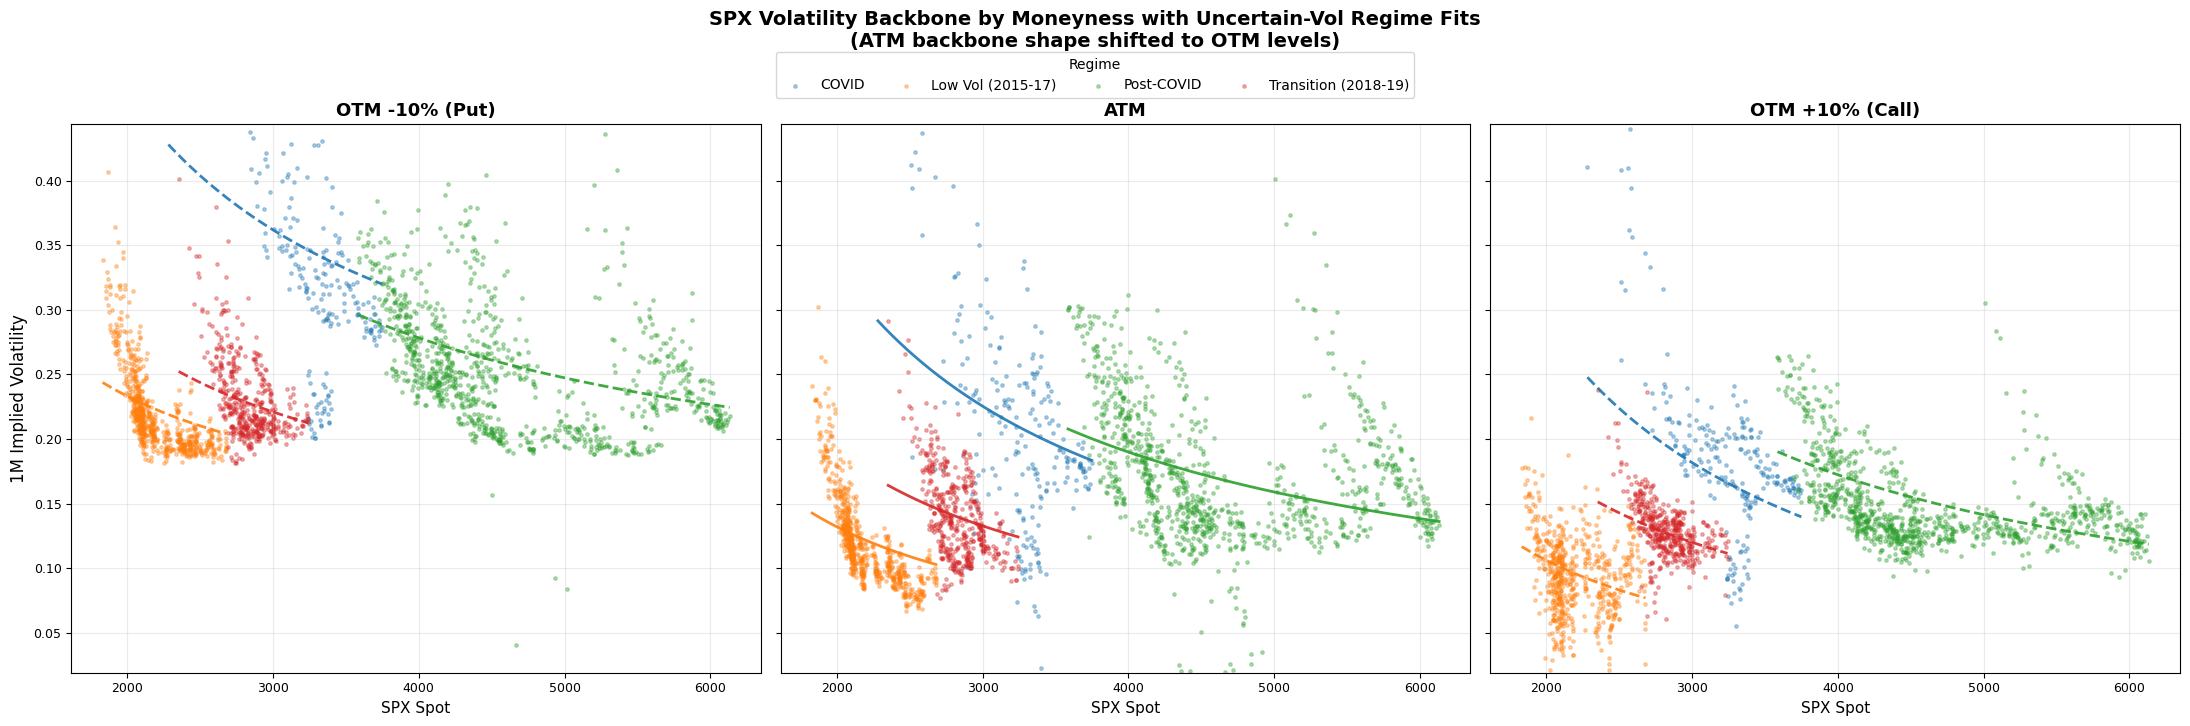

Saved: ./processed_data/backbone_10k_subplots.png


In [53]:
# ---------------------------------------------------------
# Figure 1: OTM-10_k  |  ATM  |  OTM+10_k  (Shared Y-Axis)
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

panels = [
    (-0.10, 'OTM -10% (Put)', axes[0]),
    (0.00,  'ATM',            axes[1]),
    (+0.10, 'OTM +10% (Call)', axes[2])
]

all_ivs = []
for k_val, _, _ in panels:
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]
    all_ivs.extend(subset['iv_1m'].tolist())

y_min, y_max = np.percentile(all_ivs, [1, 99])
y_pad = (y_max - y_min) * 0.1

for k_val, title, ax in panels:

    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]

    for reg, g in subset.groupby('regime'):
        ax.scatter(
            g['spot'], g['iv_1m'],
            s=6, alpha=0.35,
            color=regime_colors.get(reg, 'gray'),
            label=reg
        )

    for reg, fit_info in fits_regime_mse.items():
        params = fit_info['params']
        raw_w = params[:3]
        weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
        betas = params[3:6]
        sigmas_ln = np.abs(params[6:9])

        reg_data = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]
        if len(reg_data) == 0:
            continue
        S_ref = reg_data['spot'].mean()
        sigmas_n = list(np.array(sigmas_ln) * S_ref)

        S_min = reg_data['spot'].min()
        S_max = reg_data['spot'].max()
        S_grid = np.linspace(S_min, S_max, 150)

        if k_val == 0:
            # ATM: use backbone directly
            fitted = [
                op.uncertain_backbone(S, S, 0.02, TARGET_TAU,
                    weights, betas, sigmas_n, sigmas_ln)
                for S in S_grid
            ]
        else:
            # OTM: shift the ATM backbone to match the regime's mean OTM IV level
            atm_iv = [
                op.uncertain_backbone(S, S, 0.02, TARGET_TAU,
                    weights, betas, sigmas_n, sigmas_ln)
                for S in S_grid
            ]
            atm_mean = np.mean(atm_iv)
            otm_mean = subset[subset['regime'] == reg]['iv_1m'].mean()
            fitted = [v - atm_mean + otm_mean for v in atm_iv]

        ax.plot(
            S_grid, fitted,
            color=regime_colors.get(reg, 'gray'),
            linewidth=2.0, alpha=0.9,
            linestyle='-' if k_val == 0 else '--'
        )

    ax.set_xlabel('SPX Spot', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('1M Implied Volatility', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center', ncol=4, fontsize=10,
    bbox_to_anchor=(0.5, 0.98), title='Regime'
)

plt.suptitle(
    'SPX Volatility Backbone by Moneyness with Uncertain-Vol Regime Fits\n'
    '(ATM backbone shape shifted to OTM levels)',
    fontsize=14, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('./processed_data/backbone_10k_subplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ./processed_data/backbone_10k_subplots.png")


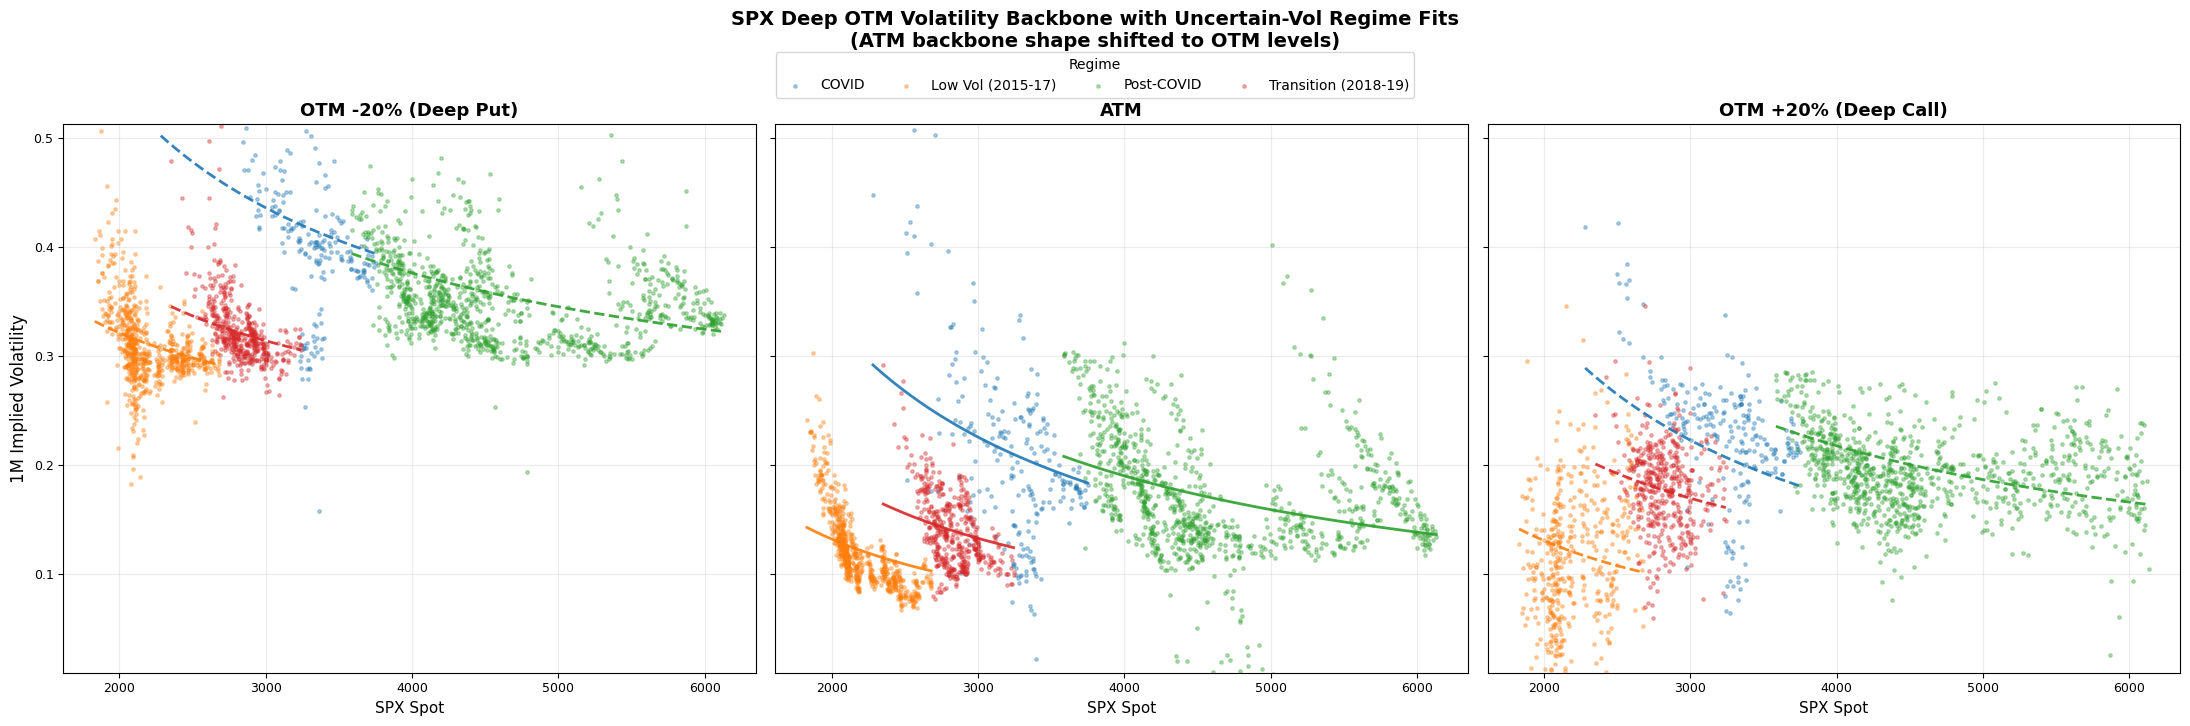

Saved: ./processed_data/backbone_20k_subplots.png


In [54]:
# ---------------------------------------------------------
# Figure 2: OTM-20_k  |  ATM  |  OTM+20_k  (Shared Y-Axis)
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

panels_20 = [
    (-0.20, 'OTM -20% (Deep Put)', axes[0]),
    (0.00,  'ATM',                axes[1]),
    (+0.20, 'OTM +20% (Deep Call)', axes[2])
]

all_ivs_20 = []
for k_val, _, _ in panels_20:
    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]
    all_ivs_20.extend(subset['iv_1m'].tolist())

y_min_20, y_max_20 = np.percentile(all_ivs_20, [1, 99])
y_pad_20 = (y_max_20 - y_min_20) * 0.1

for k_val, title, ax in panels_20:

    subset = iv1m_k_pc_df[iv1m_k_pc_df['k'] == k_val]

    for reg, g in subset.groupby('regime'):
        ax.scatter(
            g['spot'], g['iv_1m'],
            s=6, alpha=0.35,
            color=regime_colors.get(reg, 'gray'),
            label=reg
        )

    for reg, fit_info in fits_regime_mse.items():
        params = fit_info['params']
        raw_w = params[:3]
        weights = np.exp(raw_w) / np.sum(np.exp(raw_w))
        betas = params[3:6]
        sigmas_ln = np.abs(params[6:9])

        reg_data = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]
        if len(reg_data) == 0:
            continue
        S_ref = reg_data['spot'].mean()
        sigmas_n = list(np.array(sigmas_ln) * S_ref)

        S_min = reg_data['spot'].min()
        S_max = reg_data['spot'].max()
        S_grid = np.linspace(S_min, S_max, 150)

        if k_val == 0:
            fitted = [
                op.uncertain_backbone(S, S, 0.02, TARGET_TAU,
                    weights, betas, sigmas_n, sigmas_ln)
                for S in S_grid
            ]
        else:
            atm_iv = [
                op.uncertain_backbone(S, S, 0.02, TARGET_TAU,
                    weights, betas, sigmas_n, sigmas_ln)
                for S in S_grid
            ]
            atm_mean = np.mean(atm_iv)
            otm_mean = subset[subset['regime'] == reg]['iv_1m'].mean()
            fitted = [v - atm_mean + otm_mean for v in atm_iv]

        ax.plot(
            S_grid, fitted,
            color=regime_colors.get(reg, 'gray'),
            linewidth=2.0, alpha=0.9,
            linestyle='-' if k_val == 0 else '--'
        )

    ax.set_xlabel('SPX Spot', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(y_min_20 - y_pad_20, y_max_20 + y_pad_20)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('1M Implied Volatility', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center', ncol=4, fontsize=10,
    bbox_to_anchor=(0.5, 0.98), title='Regime'
)

plt.suptitle(
    'SPX Deep OTM Volatility Backbone with Uncertain-Vol Regime Fits\n'
    '(ATM backbone shape shifted to OTM levels)',
    fontsize=14, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('./processed_data/backbone_20k_subplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ./processed_data/backbone_20k_subplots.png")


## Thoughts on the Work So Far

### Strengths

1. **Data Quality & Coverage:** The dataset spans ~10 years (2015–2025) with daily observations, capturing multiple distinct regimes (low vol, COVID, post-COVID). This is a robust empirical foundation.

2. **Methodological Rigor:** Interpolating in total-variance space (rather than raw IV) is the correct approach — it avoids the calendar-spread arbitrage that can arise from naive IV interpolation.

3. **Regime Decomposition:** Splitting by regime rather than by year is more economically meaningful. Years are arbitrary; regimes (low vol, transition, crisis, recovery) reflect the true stochastic process driving the backbone.

4. **Uncertain Vol Framework:** The 3-state displaced-diffusion model is well-suited to this problem. It captures:
   - **Level shifts** (via $\sigma_{ln}$)
   - **Skew/asymmetry** (via $eta < 1$)
   - **Mixture dynamics** (via weights across states)

### Weaknesses & Open Questions

1. **Static Parameters:** The model fits a *single* set of parameters per regime. But within a regime (e.g., Post-COVID 2021–2025), the backbone may still drift. A time-varying parameter approach (e.g., rolling window, Kalman filter) could improve fit.

2. **Put-Call Divergence at OTM:** We now use actual put IVs for negative k, which is more accurate. However, for deep OTM puts (k = -0.20), liquidity is poor and bid-ask spreads are wide. The `put_mid` may not reflect the true marginal price — the effective IV could be closer to the ask.

3. **Fixed Maturity Only:** We focus on 1M ATM. The backbone slope likely varies with maturity (term structure of backbone). A 3D surface (spot × moneyness × maturity) would be the natural next step.

4. **Risk-Neutral vs Real-World:** The backbone is a risk-neutral object. Its shape reflects both:
   - **Objective dynamics** (volatility of volatility)
   - **Risk premia** (crash aversion, skewness premium)
   Disentangling these requires additional data (e.g., realized volatility, VIX futures).

5. **Parameter Identification:** With 9 parameters and only ~2,400 ATM observations per regime, the model may be slightly over-parameterised. The L-BFGS-B bounds help, but some parameter combinations may be observationally equivalent.

### Next Steps

1. **Out-of-sample testing:** Hold out 2024 data, fit on 2015–2023, and test predictive accuracy.
2. **Rolling window fits:** Estimate parameters on a 2-year rolling window to visualise parameter drift.
3. **Compare with parametric models:** Benchmark against simpler models (e.g., constant elasticity of variance, Heston) to justify the extra complexity.
4. **Economic interpretation:** Link fitted parameters to macro variables (VIX, credit spreads, Fed policy) to give the backbone a structural interpretation.
